# DO vs HO vs DOHO vs RL-DOHO — Feature Selection on the Rheumatic & Autoimmune Disease Dataset

Four optimizers, same evaluation budget (POP_SIZE subsets per iteration):

1. **DO**: Dandelion Optimizer
2. **HO**: Hippopotamus Optimization
3. **DOHO**: fixed-switch hybrid (DO first, then HO)
4. **RL-DOHO** (proposed), a DO + HO hybrid with a reinforcement-learning controller (a UCB multi-armed bandit):
   - **DO exploration:** DO's movement equations, unchanged, while the search is improving.
   - **Stagnation trigger:** when the global best hasn't improved for `STAG_TRIGGER` iterations, the **UCB bandit** chooses one of four arms:
     - **PERTURB:** tabu local search, flipping 1–3 features of the best subset.
     - **RESTART:** tabu random re-seeding of the worst half.
     - **DO:** DO's movement.
     - **HO:** HO's movement.

     The reward is 1 for a new global best; otherwise up to 0.2, for the share of the arm's candidates that beat the population median.
   - **Tabu memory:** stops the search re-evaluating subsets it has already visited.
   - **Elitism:** keeps the best subset found so far in the population.
   - **Parsimony tie-break:** if two subsets' fitness is within `TIE_EPS` (0.001, about the CV noise level), the one with fewer features is kept. Each feature is a lab test, so a smaller subset is cheaper for the patient.

**Why a bandit, not Q-learning?** An earlier RL-DOHO used a Q-table, which gets only about 20 decisions per run, too few to learn from. In ablation it did worse than a random controller. A bandit has no states, so it learns usefully from 20 decisions. The old Q-learning version is kept in the ablation (section 9) for comparison.

**What it covers**
- Every iteration of every algorithm is printed: action, best, generation-best, mean, feature count, mask, diversity, new evaluations and time.
- One figure per algorithm (convergence, feature count, mask-over-iterations heatmap, diversity), plus RL-DOHO's bandit diagnostics (arm choices, pulls, rewards).
- A multi-seed benchmark with boxplots, mean convergence ± std, feature-selection frequency, confusion matrices, and Friedman + Wilcoxon tests.
- **Is the gap real?** McNemar test and bootstrap 95% CIs on test accuracy, plus an accuracy-vs-features (Pareto) plot.
- **Ablation** (each row removes or replaces one component):
  - the bandit replaced by a random arm choice, or by PERTURB only;
  - no HO arm;
  - no parsimony tie-break;
  - the old Q-learning controller;
  - no local search at all (plain DO).
- A **ceiling check** showing whether the algorithms are stuck at the same optimum, which explains the "can't beat DO/HO" problem.

**Leakage fixes compared to the old pipeline**
- Imputation and scaling are fit on the training split only.
- SMOTE runs *inside* each CV fold (imblearn `Pipeline`), never before CV.
- Fitness uses stratified 3-fold CV. The test set is used only in the final evaluation.

**Fitness weights** are α=0.99, β=0.01, the standard setting in wrapper feature-selection papers, so the search is accuracy-first.

**Seeds:** seed 42 was used while designing the algorithm, so it appears only in the detailed walkthrough (section 6). The benchmark uses seeds 0–9. If an earlier run's results file is on Drive, the DO / HO / DOHO runs and the old RL-DOHO variants are reused from it, so only the new RL-DOHO and its ablation need computing.

Results and fitness caches are saved to Drive, so if Colab disconnects, rerunning resumes where it left off.

In [ ]:
# ================= 0. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import subprocess, sys
try:
    import xgboost, imblearn
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost", "imbalanced-learn"], check=True)

import os, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from scipy.stats import wilcoxon, friedmanchisquare
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [ ]:
# ================= 1. CONFIG — change these =================
DATA_PATH = '/content/drive/MyDrive/Rheumatic and Autoimmune Disease Dataset.xlsx' if IN_COLAB \
            else 'Rheumatic and Autoimmune Disease Dataset.xlsx'
OUT_DIR   = '/content/drive/MyDrive/rl_doho_results' if IN_COLAB else 'rl_doho_results'

POP_SIZE   = 12        # agents per algorithm (same for all 4 -> equal evaluation budget)
MAX_ITER   = 20        # iterations per run
DETAIL_SEED = 42       # seed for the detailed single run (section 6)
SEEDS      = list(range(10))   # final benchmark (seed 42 was used during design, so it is NOT in the evaluation set)
VERBOSE    = False     # True prints every iteration of every benchmark run (very long for 10 seeds)
RUN_ABLATION = True    # section 9: which RL-DOHO components matter

CV_FOLDS   = 3         # folds inside the fitness function
FIT_TREES  = 60        # trees per model inside fitness (cheap)
EVAL_TREES = 200       # trees per model for the final test evaluation
USE_SMOTE  = True      # SMOTE inside each CV fold / final training
ALPHA, BETA = 0.99, 0.01   # fitness = ALPHA*(1-acc) + BETA*(n_selected/n_features)
FITNESS_SUBSAMPLE = 4000   # stratified subset of train used ONLY inside fitness (~2s/eval). None = full train (~3.5s/eval)

os.makedirs(OUT_DIR, exist_ok=True)
ALGOS  = ["DO", "HO", "DOHO", "RL-DOHO"]
PROPOSED = "RL-DOHO"
COLORS = {"DO": "#2a78d6", "HO": "#eb6834", "DOHO": "#1baf7a", "RL-DOHO": "#eda100"}
STAG_TRIGGER = 2       # RL-DOHO: iterations without improvement before the bandit takes over
UCB_C        = 1.0     # UCB exploration constant
TABU_TENURE  = None    # None = remember every subset evaluated in the run (fine for 2^14 subsets); or an int, e.g. 10 iterations
TIE_EPS      = 0.001   # RL-DOHO parsimony tie-break: fitness within TIE_EPS (about CV noise) counts as a tie -> fewer features wins
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})
print("Output folder:", OUT_DIR)

Output folder: /content/drive/MyDrive/rl_doho_results


## 2. Load data and preprocess (no leakage)

In [ ]:
df = pd.read_excel(DATA_PATH)
numeric_cols = ['Age', 'ESR', 'CRP', 'RF', 'Anti-CCP', 'C3', 'C4']
binary_cols  = ['Gender', 'HLA-B27', 'ANA', 'Anti-Ro', 'Anti-La', 'Anti-dsDNA', 'Anti-Sm']
FEATURES = numeric_cols + binary_cols
N_FEATURES = len(FEATURES)

# Binary columns -> 1/0 explicitly (LabelEncoder on a column with NaN filled by mode is fragile)
X = df[FEATURES].copy()
for c in binary_cols:
    X[c] = X[c].astype(str).str.strip().str.lower().map(
        {'male': 1, 'female': 0, 'positive': 1, 'negative': 0, 'yes': 1, 'no': 0})
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Disease'].astype(str))
CLASS_NAMES = list(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True)

# Imputation + scaling fitted on TRAIN only
num_imp = SimpleImputer(strategy='mean').fit(X_train[numeric_cols])
bin_imp = SimpleImputer(strategy='most_frequent').fit(X_train[binary_cols])
scaler  = StandardScaler().fit(num_imp.transform(X_train[numeric_cols]))
def prep(Xp):
    out = Xp.copy()
    out[numeric_cols] = scaler.transform(num_imp.transform(Xp[numeric_cols]))
    out[binary_cols]  = bin_imp.transform(Xp[binary_cols])
    return out.astype(float)
X_train, X_test = prep(X_train), prep(X_test)

# Optional stratified subsample used ONLY by the fitness function (speed)
if FITNESS_SUBSAMPLE and FITNESS_SUBSAMPLE < len(X_train):
    X_fit, _, y_fit, _ = train_test_split(X_train, y_train, train_size=FITNESS_SUBSAMPLE, stratify=y_train, random_state=0)
    X_fit = X_fit.reset_index(drop=True)
else:
    X_fit, y_fit = X_train, y_train

print("Rows:", len(df), "| features:", N_FEATURES, "| classes:", len(CLASS_NAMES))
print("Train:", X_train.shape, "Test:", X_test.shape, "Fitness set:", X_fit.shape)
print("Search space size: 2^%d - 1 = %d possible feature subsets" % (N_FEATURES, 2**N_FEATURES - 1))

Rows: 12085 | features: 14 | classes: 7
Train: (9668, 14) Test: (2417, 14) Fitness set: (4000, 14)
Search space size: 2^14 - 1 = 16383 possible feature subsets


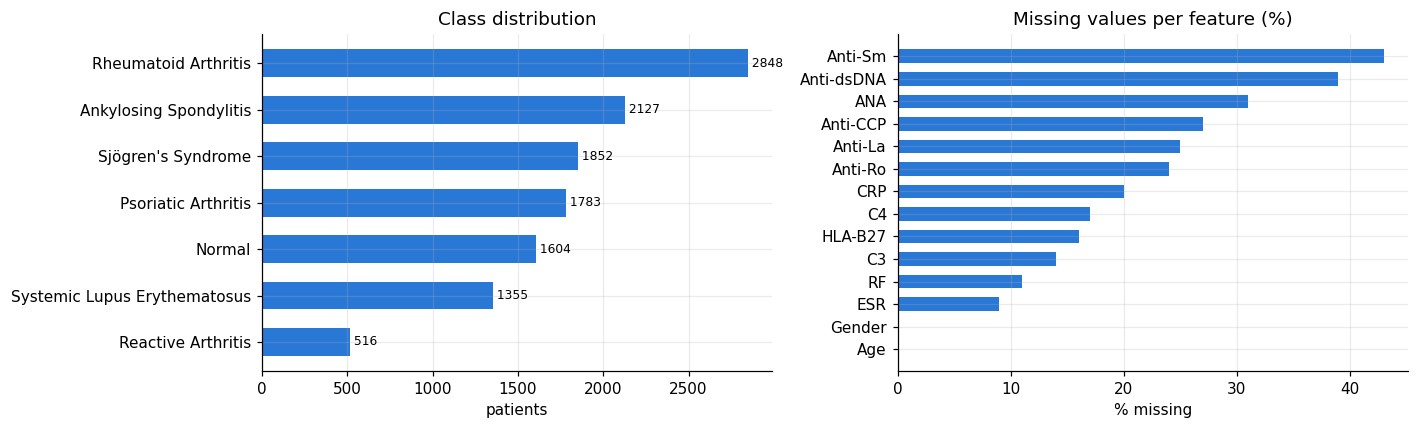

In [ ]:
# EDA: class balance and missingness
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vc = df['Disease'].value_counts()
ax[0].barh(vc.index[::-1], vc.values[::-1], color="#2a78d6", height=0.6)
ax[0].set_title("Class distribution"); ax[0].set_xlabel("patients")
for i, v in enumerate(vc.values[::-1]): ax[0].text(v, i, f" {v}", va='center', fontsize=8)
miss = df[FEATURES].isna().mean().sort_values() * 100
ax[1].barh(miss.index, miss.values, color="#2a78d6", height=0.6)
ax[1].set_title("Missing values per feature (%)"); ax[1].set_xlabel("% missing")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/00_eda.png", bbox_inches='tight'); plt.show()

## 3. Fitness function (cached, CV with SMOTE inside each fold) and test evaluation

In [ ]:
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

def make_models(n_trees):
    xgb = XGBClassifier(n_estimators=n_trees, max_depth=4, learning_rate=0.1, random_state=42,
                        tree_method='hist', verbosity=0, n_jobs=-1)
    hgb = HistGradientBoostingClassifier(max_iter=n_trees, max_depth=4, random_state=42)
    if USE_SMOTE:
        xgb = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', xgb)])
        hgb = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', hgb)])
    return xgb, hgb

CACHE_FILE = f"{OUT_DIR}/fitness_cache_{FIT_TREES}t_{CV_FOLDS}f_{int(USE_SMOTE)}s_{FITNESS_SUBSAMPLE}.pkl"
_cache = pickle.load(open(CACHE_FILE, 'rb')) if os.path.exists(CACHE_FILE) else {}
for _k, _v in _cache.items():   # re-score cached masks under the current ALPHA/BETA (accuracy is what's stored)
    _n = _k.count("1"); _v["fit"] = 1.0 if _n == 0 else ALPHA * (1 - _v["acc"]) + BETA * _n / len(_k)
print(f"Fitness cache loaded: {len(_cache)} masks already evaluated (re-scored with ALPHA={ALPHA}, BETA={BETA})")
COUNTER = {"calls": 0, "new": 0}

def mask_str(m): return ''.join(map(str, np.asarray(m).astype(int)))

def fitness_function(mask, X_tr=None, y_tr=None):
    # Deterministic, so caching is fair to every algorithm.
    COUNTER["calls"] += 1
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    Xs = X_fit.iloc[:, sel]
    xgb, hgb = make_models(FIT_TREES)
    acc = (cross_val_score(xgb, Xs, y_fit, cv=CV).mean() + cross_val_score(hgb, Xs, y_fit, cv=CV).mean()) / 2
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}
    COUNTER["new"] += 1
    if COUNTER["new"] % 10 == 0:                       # heartbeat: one dot per 10 new model trainings
        print(".", end="", flush=True)
        if COUNTER["new"] % 200 == 0: save_cache()
    return f

def save_cache(): pickle.dump(_cache, open(CACHE_FILE, 'wb'))

_test_cache = {}
def evaluate_on_test(mask, name="", verbose=True):
    key = mask_str(mask)
    if key not in _test_cache:
        idx = np.flatnonzero(mask)
        res = {}
        for mname, m in zip(["XGB", "HGB"], make_models(EVAL_TREES)):
            m.fit(X_train.iloc[:, idx], y_train)
            p = m.predict(X_test.iloc[:, idx])
            res[mname] = {"acc": accuracy_score(y_test, p), "f1": f1_score(y_test, p, average='macro'), "pred": p}
        res["acc"] = np.mean([res["XGB"]["acc"], res["HGB"]["acc"]])
        res["f1"]  = np.mean([res["XGB"]["f1"],  res["HGB"]["f1"]])
        _test_cache[key] = res
    r = _test_cache[key]
    if verbose:
        print(f"{name:8s} XGB acc={r['XGB']['acc']:.4f}  HGB acc={r['HGB']['acc']:.4f}  avg acc={r['acc']:.4f}  "
              f"macro-F1={r['f1']:.4f}  feats={int(np.sum(mask))}  mask={key}")
    return r

t = time.time(); f_all = fitness_function(np.ones(N_FEATURES, int))
print(f"One fitness evaluation took {time.time()-t:.1f}s  (fitness with ALL features = {f_all:.4f})")
print("Baseline with all features:")
_ = evaluate_on_test(np.ones(N_FEATURES, int), "ALL")

Fitness cache loaded: 2640 masks already evaluated (re-scored with ALPHA=0.99, BETA=0.01)
One fitness evaluation took 0.0s  (fitness with ALL features = 0.1884)
Baseline with all features:
ALL      XGB acc=0.8444  HGB acc=0.8349  avg acc=0.8397  macro-F1=0.8350  feats=14  mask=11111111111111


## 4. Shared helpers: binarization and the per-iteration logger

In [ ]:
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def binarize(position): return (sigmoid(position) > 0.5).astype(int)

class IterLogger:
    # Records and prints every iteration of a run.
    def __init__(self, algo, seed, verbose=True):
        self.algo, self.seed, self.verbose = algo, seed, verbose
        self.rows, self.t0, self.seen = [], time.time(), set()
        if verbose:
            print(f"\n{'='*118}\n{algo}  | seed={seed} | pop={POP_SIZE} | iters={MAX_ITER}\n{'='*118}")
            print(f"{'iter':>4} | {'action':<14}| {'best':>7} {'genbest':>7} {'mean':>7} {'worst':>7} | "
                  f"{'#f':>2} | {'best mask':<{N_FEATURES}} | {'div':>5} | {'new':>3} | {'sec':>5}")

    def log(self, t, action, positions, fitness, best_fit, best_mask, reward=None):
        pm = np.array([binarize(p) for p in positions])
        fresh = {mask_str(m) for m in pm} - self.seen; new = len(fresh); self.seen |= fresh
        row = dict(iter=t, action=action, best=best_fit, gen_best=float(np.min(fitness)),
                   mean=float(np.mean(fitness)), worst=float(np.max(fitness)),
                   n_feats=int(best_mask.sum()), best_mask=best_mask.copy(),
                   pop_masks=pm,
                   diversity=float(np.mean(np.std(positions, axis=0))), new_evals=new,
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = f" r={reward:+.3f}" if reward is not None else ""
            print(f"{t:>4} | {action:<14}| {row['best']:.4f} {row['gen_best']:.4f} {row['mean']:.4f} {row['worst']:.4f} | "
                  f"{row['n_feats']:>2} | {mask_str(best_mask)} | {row['diversity']:.3f} | {new:>3} | {row['sec']:5.1f}{rw}")
        self.t0 = time.time()

    def finish(self, best_fit, best_mask):
        if self.verbose:
            sel = [FEATURES[i] for i in np.flatnonzero(best_mask)]
            print(f"    ('new' = subsets this run had not evaluated before; {len(self.seen)} distinct subsets in total)")
            print(f"--> {self.algo} done: best fitness={best_fit:.4f}, CV acc={_cache[mask_str(best_mask)]['acc']:.4f}, "
                  f"{len(sel)} features: {sel}")
        save_cache()
        return pd.DataFrame(self.rows)

## 5. The algorithms (original DO / HO update rules plus per-iteration logging)

In [ ]:
def _init(rng, dim):
    positions = rng.uniform(-1, 1, size=(POP_SIZE, dim))
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    b = np.argmin(fitness)
    return positions, masks, fitness, positions[b].copy(), masks[b].copy(), fitness[b]

def _evaluate_and_update(positions, fitness, best_position, best_mask, best_fitness, t):
    # Elitism (worst of previous generation gets the best), evaluate, update the global best.
    worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1
    positions[worst_idx] = best_position.copy()
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    g = np.argmin(fitness); improved = fitness[g] < best_fitness
    if improved:
        best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
    return masks, fitness, best_position, best_mask, best_fitness, improved

# ---------------- DO ----------------
def dandelion_optimizer(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "rising" if progress < 0.4 else ("descending" if progress < 0.8 else "landing")
        for i in range(POP_SIZE):
            if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
            elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:                positions[i] += rng.normal(0, 0.1, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, phase, positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- HO ----------------
def hippopotamus_optimization(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("HO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        n_mv = [0, 0, 0]
        for i in range(POP_SIZE):
            r = rng.random()
            if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6; n_mv[0] += 1
            elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i]); n_mv[1] += 1
            else:         positions[i] += rng.normal(0, 0.6, dim); n_mv[2] += 1
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"mv{n_mv[0]}/df{n_mv[1]}/ev{n_mv[2]}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- Fixed DOHO ----------------
def doho_fixed(seed=42, verbose=True, switch_point=0.5):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DOHO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "DO" if progress <= switch_point else "HO"
        for i in range(POP_SIZE):
            if phase == "DO":
                if progress < switch_point * 0.6: positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                else: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"phase {phase}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

In [ ]:
# ---------------- Previous RL-DOHO (Q-learning controller, v10): used only in the ablation ----------------
ACTION_NAMES = {0: "DO", 1: "HO", 2: "PERTURB", 3: "RESTART"}

class QLearningController:
    def __init__(self, n_actions=4, alpha=0.5, gamma=0.5, epsilon=0.3, epsilon_decay=0.85, seed=42):
        self.rng = np.random.default_rng(seed); self.q_table = {}
        self.alpha, self.gamma, self.epsilon, self.epsilon_decay, self.n_actions = alpha, gamma, epsilon, epsilon_decay, n_actions
    def get_state(self, positions, stagnation, progress):
        div = np.mean(np.std(positions, axis=0))
        return (int(div >= 0.8), int(stagnation >= 3), int(progress >= 0.5))
    def _q(self, s):
        if s not in self.q_table: self.q_table[s] = np.zeros(self.n_actions)
        return self.q_table[s]
    def choose_action(self, state):
        q = self._q(state)
        if self.rng.random() < self.epsilon: return int(self.rng.integers(0, self.n_actions)), "explore"
        best = np.flatnonzero(q == q.max())                 # random tie-break, not always action 0
        return int(self.rng.choice(best)), "greedy"
    def update(self, s, a, r, s2):
        q = self._q(s); q[a] += self.alpha * (r + self.gamma * np.max(self._q(s2)) - q[a])
    def decay_epsilon(self): self.epsilon = max(0.05, self.epsilon * self.epsilon_decay)

def rl_doho_qlearning(seed=42, verbose=True, perturb_frac=0.15, controller=None, name="RL-DOHO (Q-learning)"):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = controller(seed) if controller else QLearningController(seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    stagnation = 0; k = max(1, int(round(dim * perturb_frac)))
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        state = agent.get_state(positions, stagnation, progress)
        action, how = agent.choose_action(state)
        order = np.argsort(fitness); worst_half = set(order[POP_SIZE // 2:])
        prev_top = np.mean(np.sort(fitness)[:POP_SIZE // 2]); prev_best = best_fitness
        for i in range(POP_SIZE):
            if action == 0:                                   # DO move
                if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
                else:                positions[i] += rng.normal(0, 0.1, dim)
            elif action == 1:                                 # HO move
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            elif i in worst_half:                             # disruptive actions only hit the worst half
                if action == 2:                               # flip k bits of the best solution
                    p = best_position.copy(); d = rng.choice(dim, k, replace=False)
                    p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); positions[i] = p
                else:                                         # restart
                    positions[i] = rng.uniform(-1, 1, dim)
            else:                                             # good half keeps exploiting
                positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            positions[i] = np.clip(positions[i], -3, 3)
        positions[order[-1]] = best_position.copy()          # elitism
        masks = np.array([binarize(p) for p in positions])
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness:
            best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy(); stagnation = 0
        else:
            stagnation += 1
        new_top = np.mean(np.sort(fitness)[:POP_SIZE // 2])
        reward = 100 * (prev_best - best_fitness) + 10 * (prev_top - new_top)
        agent.update(state, action, reward, agent.get_state(positions, stagnation, min((t + 1) / MAX_ITER, 1.0)))
        agent.decay_epsilon()
        L.log(t, f"{ACTION_NAMES[action]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["rl_action"] = ["init"] + [a.split("(")[0] for a in hist["action"][1:]]
    hist.attrs["q_table"] = {s: q.copy() for s, q in agent.q_table.items()}
    return best_mask, best_fitness, hist

RUNNERS = {"DO": dandelion_optimizer, "HO": hippopotamus_optimization, "DOHO": doho_fixed}

In [ ]:
# ---------------- RL-DOHO (proposed): DO + HO + UCB bandit controller ----------------
ARMS = ("PERTURB", "RESTART", "DO", "HO")

class UCBBandit:
    # UCB1 multi-armed bandit (single-state reinforcement learning). Rewards are in [0, 1].
    def __init__(self, n_arms=3, c=1.0, seed=42):
        self.rng = np.random.default_rng(seed); self.c = c
        self.n = np.zeros(n_arms); self.value = np.zeros(n_arms)
    def choose(self):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "init"
        ucb = self.value + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "ucb"
    def update(self, arm, r):
        self.n[arm] += 1; self.value[arm] += (r - self.value[arm]) / self.n[arm]

class RandomArm(UCBBandit):              # ablation: same trigger, arm chosen at random
    def choose(self): return int(self.rng.integers(len(self.n))), "random"

class FixedArm(UCBBandit):               # ablation: same trigger, always the same arm
    def __init__(self, arm, seed, n_arms=4): super().__init__(n_arms=n_arms, seed=seed); self.arm = arm
    def choose(self): return self.arm, "fixed"

def _do_move(rng, pos, best_position, progress, dim):
    # DO's movement equations, unchanged
    if progress < 0.4:   pos = pos + rng.normal(0, 1, dim) * (1 - progress)
    elif progress < 0.8: pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.5
    else:                pos = pos + rng.normal(0, 0.1, dim)
    return np.clip(pos, -3, 3)

def _ho_move(rng, pos, best_position, dim):
    # HO's movement equations, unchanged
    r = rng.random()
    if r < 0.5:   pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.6
    elif r < 0.8: pos = pos + rng.uniform(0.2, 0.7) * (best_position - pos)
    else:         pos = pos + rng.normal(0, 0.6, dim)
    return np.clip(pos, -3, 3)

def rl_doho(seed=42, verbose=True, bandit=None, name="RL-DOHO", arms=ARMS, k_max=3, tabu_tries=20, tie_eps=None):
    tie_eps = TIE_EPS if tie_eps is None else tie_eps
    def better(f, nf, bf, bnf):   # strictly better, or a tie within tie_eps with fewer features
        return f < bf - tie_eps or (abs(f - bf) <= tie_eps and (nf < bnf or (nf == bnf and f < bf)))
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = bandit(seed) if bandit else UCBBandit(n_arms=len(arms), c=UCB_C, seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    tabu = {mask_str(m): 0 for m in masks}            # subset -> last iteration it was visited
    def is_tabu(key, t): return key in tabu and (TABU_TENURE is None or t - tabu[key] <= TABU_TENURE)
    def tabu_draw(make, t):
        for _ in range(tabu_tries):
            p = make(); key = mask_str(binarize(p))
            if not is_tabu(key, t): break
        tabu[key] = t                                  # reserve it so two agents don't draw the same subset
        return np.clip(p, -3, 3)
    stagnation = 0

    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        prev_best, prev_median = best_fitness, float(np.median(fitness))
        order = np.argsort(fitness); worst_half = order[POP_SIZE // 2:]
        if stagnation < STAG_TRIGGER:                  # ---- improving: plain DO exploration
            arm, how = None, None
            for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
            touched = np.arange(POP_SIZE)
        else:                                          # ---- stalled: the bandit picks an arm
            arm, how = agent.choose()
            if arms[arm] == "DO":
                for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                touched = np.arange(POP_SIZE)
            elif arms[arm] == "HO":
                for i in range(POP_SIZE): positions[i] = _ho_move(rng, positions[i], best_position, dim)
                touched = np.arange(POP_SIZE)
            else:
                for i in order[:POP_SIZE // 2]:        # better half keeps DO's movement
                    positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                for i in worst_half:
                    if arms[arm] == "PERTURB":     # flip 1..k_max features of the best subset
                        def make():
                            p = best_position.copy(); k = int(rng.integers(1, k_max + 1))
                            d = rng.choice(dim, k, replace=False)
                            p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); return p
                    else:                              # RESTART: fresh random subset
                        make = lambda: rng.uniform(-1, 1, dim)
                    positions[i] = tabu_draw(make, t)
                touched = worst_half
        worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1     # elitism, same rule as DO
        positions[worst_idx] = best_position.copy()
        masks = np.array([binarize(p) for p in positions])
        for m in masks: tabu[mask_str(m)] = t
        fitness = np.array([fitness_function(m) for m in masks])
        improved = False
        for g in np.argsort(fitness):                  # best candidate under the parsimony rule
            if better(fitness[g], masks[g].sum(), best_fitness, best_mask.sum()):
                best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
                improved = True
        stagnation = 0 if improved else stagnation + 1
        if arm is None:
            L.log(t, "DO-explore", positions, fitness, best_fitness, best_mask)
        else:
            # reward: 1 for a new global best, otherwise up to 0.2 for the share of the arm's
            # candidates that beat the previous population median
            touched = [i for i in touched if i != worst_idx]
            share = np.mean([fitness[i] < prev_median for i in touched]) if touched else 0.0
            reward = 1.0 if improved else 0.2 * share
            agent.update(arm, reward)
            L.log(t, f"{arms[arm]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["arm"] = ["init"] + [("EXPLORE" if a == "DO-explore" else a.split("(")[0]) for a in hist["action"][1:]]
    hist.attrs["pulls"] = agent.n.copy(); hist.attrs["arm_value"] = agent.value.copy(); hist.attrs["arm_names"] = list(arms)
    return best_mask, best_fitness, hist

RUNNERS["RL-DOHO"] = rl_doho
print("Algorithms ready:", list(RUNNERS))

Algorithms ready: ['DO', 'HO', 'DOHO', 'RL-DOHO']


## 6. Detailed single-seed run (every iteration printed)

In [ ]:
detail = {}
for a in ALGOS:
    m, f, h = RUNNERS[a](seed=DETAIL_SEED, verbose=True)
    detail[a] = {"mask": m, "fit": f, "hist": h}
print(f"\nFitness evaluations: {COUNTER['calls']} calls, {COUNTER['new']} new model trainings (others were cache hits)")


DO  | seed=42 | pop=12 | iters=20
iter | action        |    best genbest    mean   worst | #f | best mask      |   div | new |   sec
   0 | init          | 0.2238 0.2238 0.3981 0.5703 |  8 | 01011101001011 | 0.526 |  12 |   0.0
   1 | rising        | 0.2238 0.2238 0.3820 0.6760 |  8 | 01011101001011 | 0.992 |  11 |   0.0
   2 | rising        | 0.1947 0.1947 0.3997 0.6367 | 11 | 01111111101101 | 1.327 |  10 |   0.0
   3 | rising        | 0.1865 0.1865 0.3963 0.5983 | 12 | 01111111111101 | 1.465 |  10 |   0.0
   4 | rising        | 0.1865 0.1865 0.3677 0.5806 | 12 | 01111111111101 | 1.548 |  10 |   0.0
   5 | rising        | 0.1865 0.1865 0.3105 0.5722 | 12 | 01111111111101 | 1.454 |   8 |   0.0
   6 | rising        | 0.1835 0.1835 0.2946 0.5184 | 13 | 11111111111101 | 1.475 |  10 |   0.0
   7 | rising        | 0.1822 0.1822 0.2824 0.4221 | 11 | 01111111111100 | 1.413 |   7 |   0.0
   8 | descending    | 0.1822 0.1822 0.2395 0.3582 | 11 | 01111111111100 | 0.986 |   3 |   0.0
   9 | desc

### 6a. One figure per algorithm

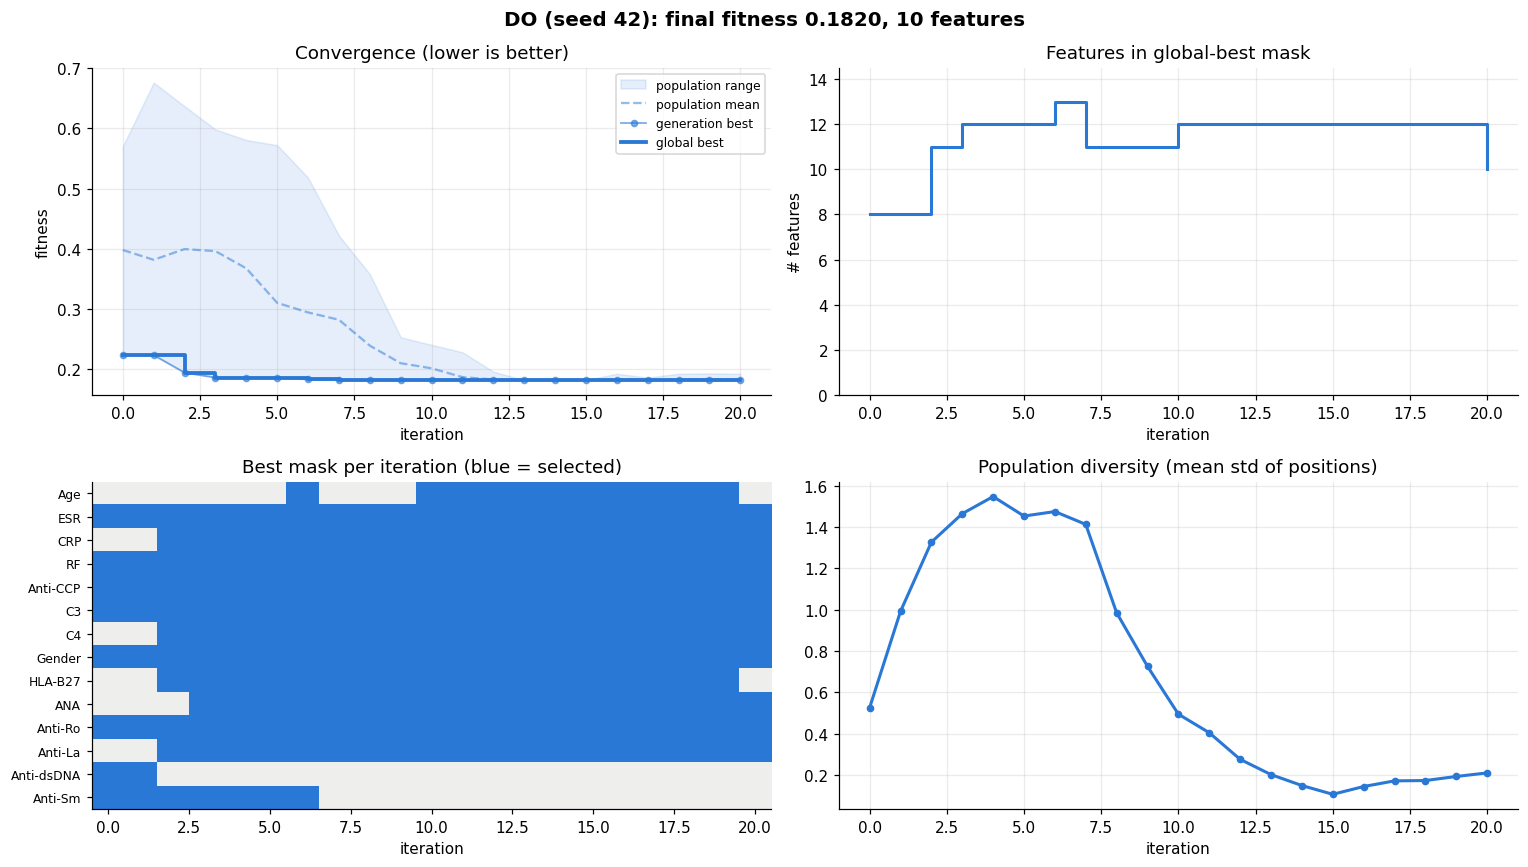

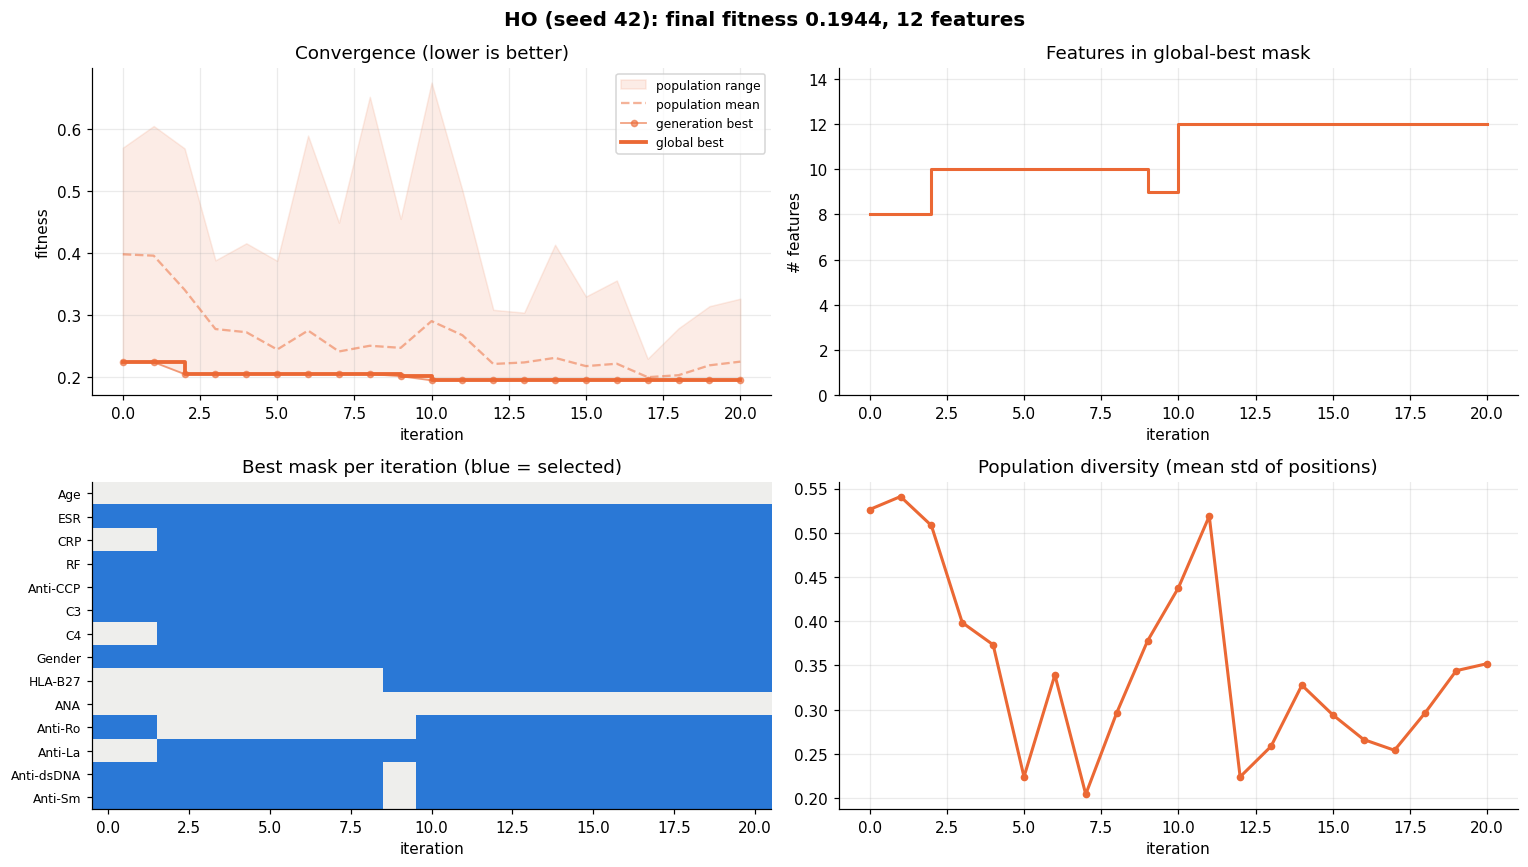

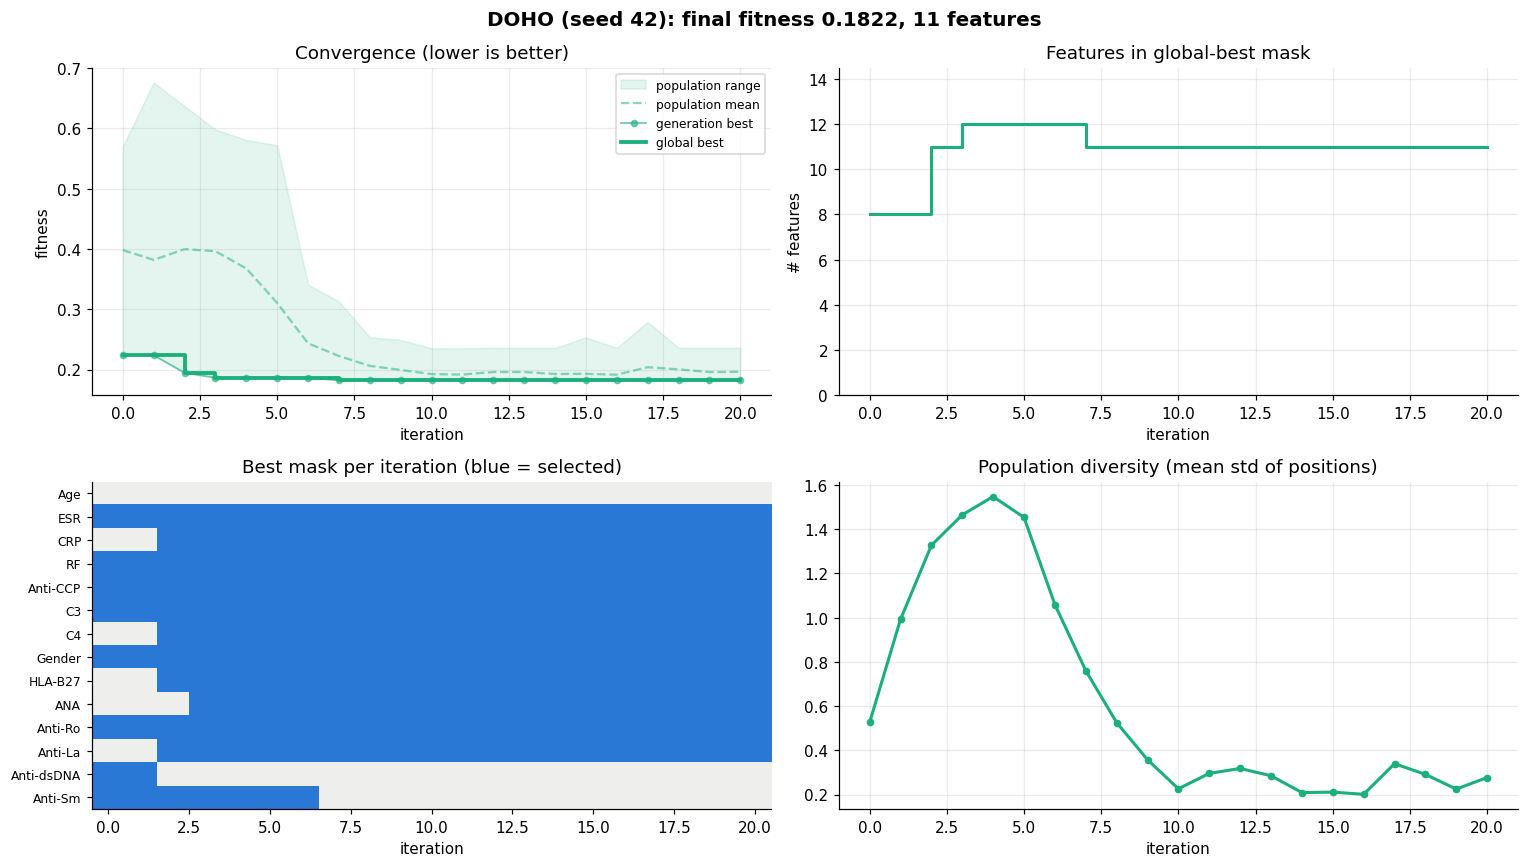

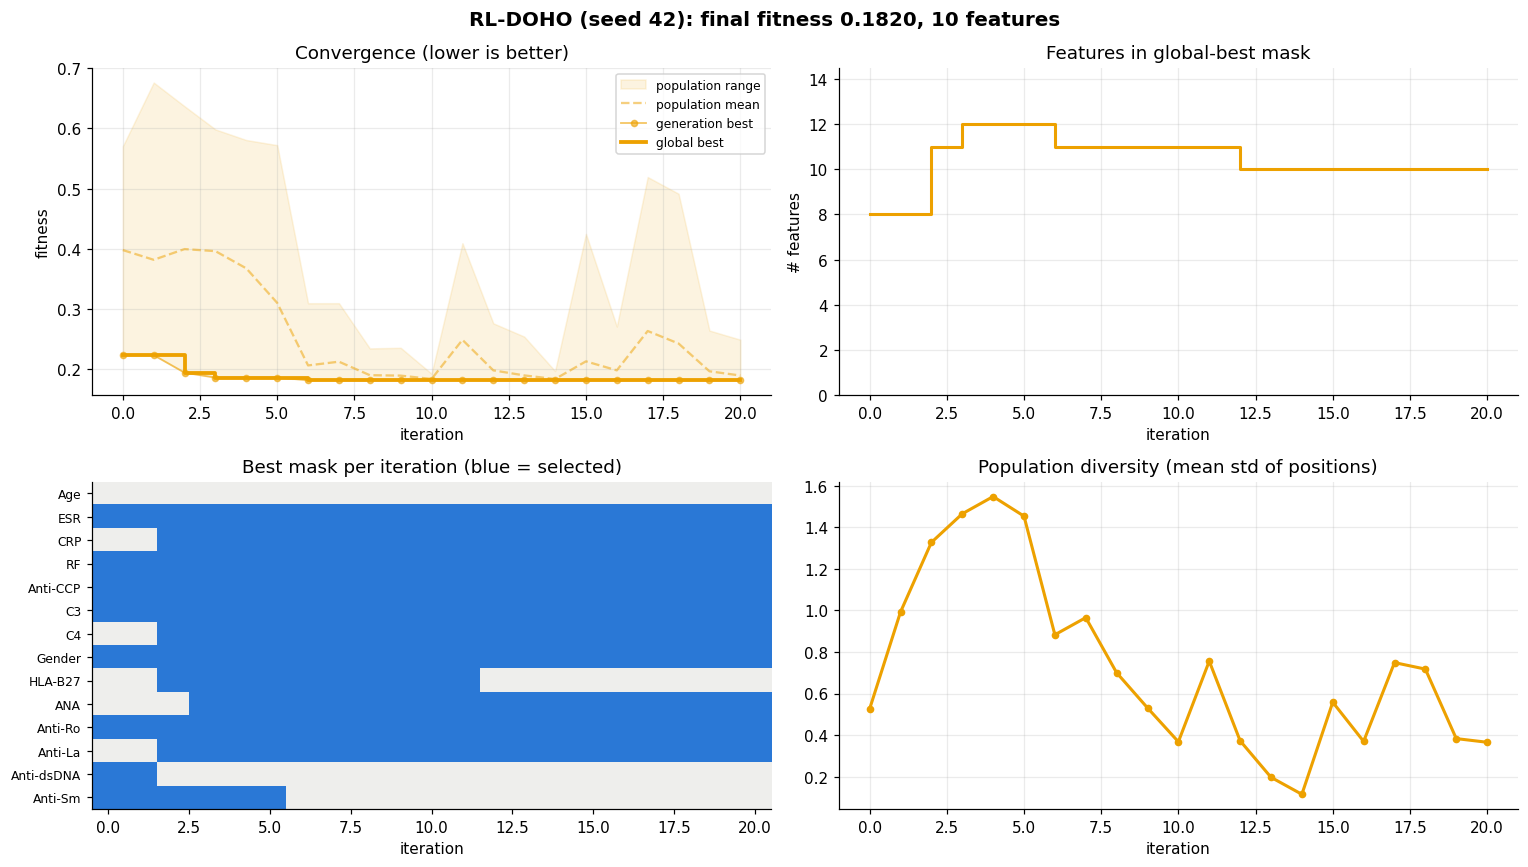

In [ ]:
feat_cmap = ListedColormap(["#eeeeec", "#2a78d6"])

def plot_algorithm(a, h, tag=""):
    c = COLORS[a]
    fig, ax = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"{a}{tag}: final fitness {h['best'].iloc[-1]:.4f}, {h['n_feats'].iloc[-1]} features", fontsize=13, fontweight='bold')
    # (1) convergence: best / generation best / mean, with worst-to-best band
    x = h["iter"]
    ax[0, 0].fill_between(x, h["gen_best"], h["worst"], color=c, alpha=0.12, label="population range")
    ax[0, 0].plot(x, h["mean"], color=c, alpha=0.5, lw=1.5, ls="--", label="population mean")
    ax[0, 0].plot(x, h["gen_best"], color=c, alpha=0.6, lw=1.2, marker="o", ms=4, label="generation best")
    ax[0, 0].step(x, h["best"], where="post", color=c, lw=2.5, label="global best")
    ax[0, 0].set_title("Convergence (lower is better)"); ax[0, 0].set_xlabel("iteration"); ax[0, 0].set_ylabel("fitness")
    ax[0, 0].legend(fontsize=8)
    # (2) features in the best mask and new evaluations per iteration
    ax[0, 1].step(x, h["n_feats"], where="post", color=c)
    ax[0, 1].set_title("Features in global-best mask"); ax[0, 1].set_xlabel("iteration"); ax[0, 1].set_ylabel("# features")
    ax[0, 1].set_ylim(0, N_FEATURES + 0.5)
    # (3) heatmap of the best mask at every iteration
    M = np.vstack(h["best_mask"].values).T
    ax[1, 0].imshow(M, aspect="auto", cmap=feat_cmap, interpolation="nearest", vmin=0, vmax=1)
    ax[1, 0].set_yticks(range(N_FEATURES)); ax[1, 0].set_yticklabels(FEATURES, fontsize=8)
    ax[1, 0].set_xlabel("iteration"); ax[1, 0].set_title("Best mask per iteration (blue = selected)"); ax[1, 0].grid(False)
    # (4) diversity
    ax[1, 1].plot(x, h["diversity"], color=c, marker="o", ms=4)
    ax[1, 1].set_title("Population diversity (mean std of positions)"); ax[1, 1].set_xlabel("iteration")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/01_{a}{tag.replace(' ', '_')}.png", bbox_inches="tight"); plt.show()

for a in ALGOS:
    plot_algorithm(a, detail[a]["hist"], f" (seed {DETAIL_SEED})")

### 6b. RL-DOHO bandit diagnostics

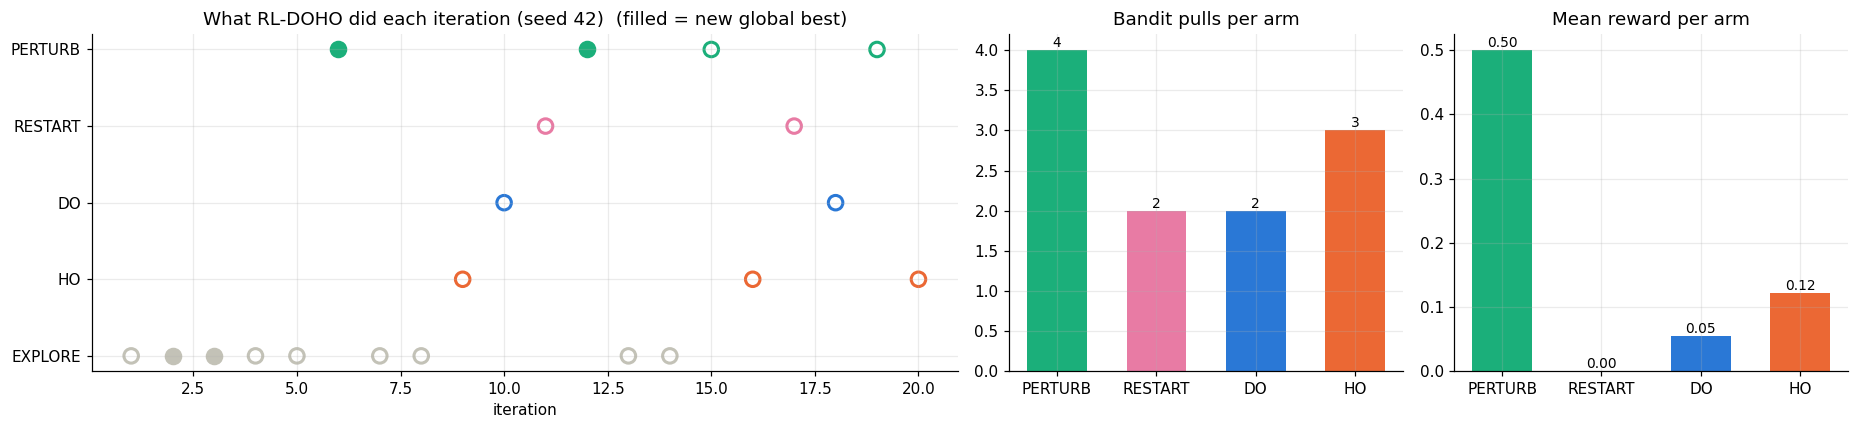

In [ ]:
ARM_COL = {"EXPLORE": "#c3c2b7", "PERTURB": "#1baf7a", "RESTART": "#e87ba4", "DO": "#2a78d6", "HO": "#eb6834"}
def plot_ucb(h, tag=""):
    hh = h.iloc[1:]
    lanes = ["EXPLORE"] + list(h.attrs.get("arm_names", ARMS))[::-1]
    improved = np.r_[False, np.diff(h["best"].values) < 0][1:]
    fig, ax = plt.subplots(1, 3, figsize=(17, 4), gridspec_kw={"width_ratios": [2.2, 1, 1]})
    for lane_i, lane in enumerate(lanes):
        sel = (hh["arm"] == lane).values
        ax[0].scatter(hh["iter"][sel & ~improved], [lane_i] * int((sel & ~improved).sum()), s=90, color=ARM_COL[lane],
                      marker="o", facecolors="none", linewidths=2)
        ax[0].scatter(hh["iter"][sel & improved], [lane_i] * int((sel & improved).sum()), s=110, color=ARM_COL[lane], marker="o")
    ax[0].set_yticks(range(len(lanes))); ax[0].set_yticklabels(lanes); ax[0].set_xlabel("iteration")
    ax[0].set_title(f"What RL-DOHO did each iteration{tag}  (filled = new global best)")
    arms = list(h.attrs.get("arm_names", ARMS)); pulls = h.attrs["pulls"]; val = h.attrs["arm_value"]
    ax[1].bar(arms, pulls, color=[ARM_COL[a] for a in arms], width=0.6); ax[1].set_title("Bandit pulls per arm")
    for i, v in enumerate(pulls): ax[1].text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=9)
    ax[2].bar(arms, val, color=[ARM_COL[a] for a in arms], width=0.6); ax[2].set_title("Mean reward per arm")
    for i, v in enumerate(val): ax[2].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/02_rl_doho_bandit.png", bbox_inches="tight"); plt.show()

plot_ucb(detail["RL-DOHO"]["hist"], f" (seed {DETAIL_SEED})")

### 6c. Side-by-side convergence and test-set evaluation for the detailed seed

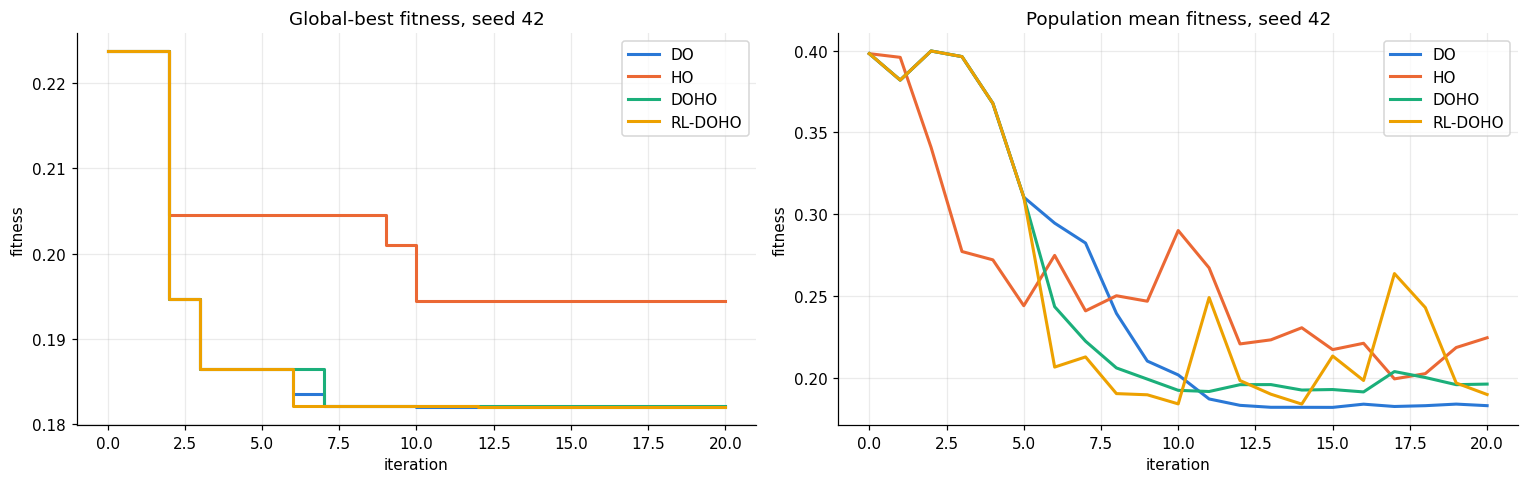

TEST-SET RESULTS (seed 42)
DO       XGB acc=0.8511  HGB acc=0.8420  avg acc=0.8465  macro-F1=0.8400  feats=10  mask=01111111011100
HO       XGB acc=0.8279  HGB acc=0.8213  avg acc=0.8246  macro-F1=0.8218  feats=12  mask=01111111101111
DOHO     XGB acc=0.8498  HGB acc=0.8424  avg acc=0.8461  macro-F1=0.8428  feats=11  mask=01111111111100
RL-DOHO  XGB acc=0.8511  HGB acc=0.8420  avg acc=0.8465  macro-F1=0.8400  feats=10  mask=01111111011100


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a in ALGOS:
    h = detail[a]["hist"]
    ax[0].step(h["iter"], h["best"], where="post", color=COLORS[a], label=a)
    ax[1].plot(h["iter"], h["mean"], color=COLORS[a], label=a)
ax[0].set_title(f"Global-best fitness, seed {DETAIL_SEED}"); ax[1].set_title(f"Population mean fitness, seed {DETAIL_SEED}")
for x_ in ax: x_.set_xlabel("iteration"); x_.set_ylabel("fitness"); x_.legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/03_overlay_seed{DETAIL_SEED}.png", bbox_inches="tight"); plt.show()

print("TEST-SET RESULTS (seed %d)" % DETAIL_SEED)
for a in ALGOS: detail[a]["test"] = evaluate_on_test(detail[a]["mask"], a)

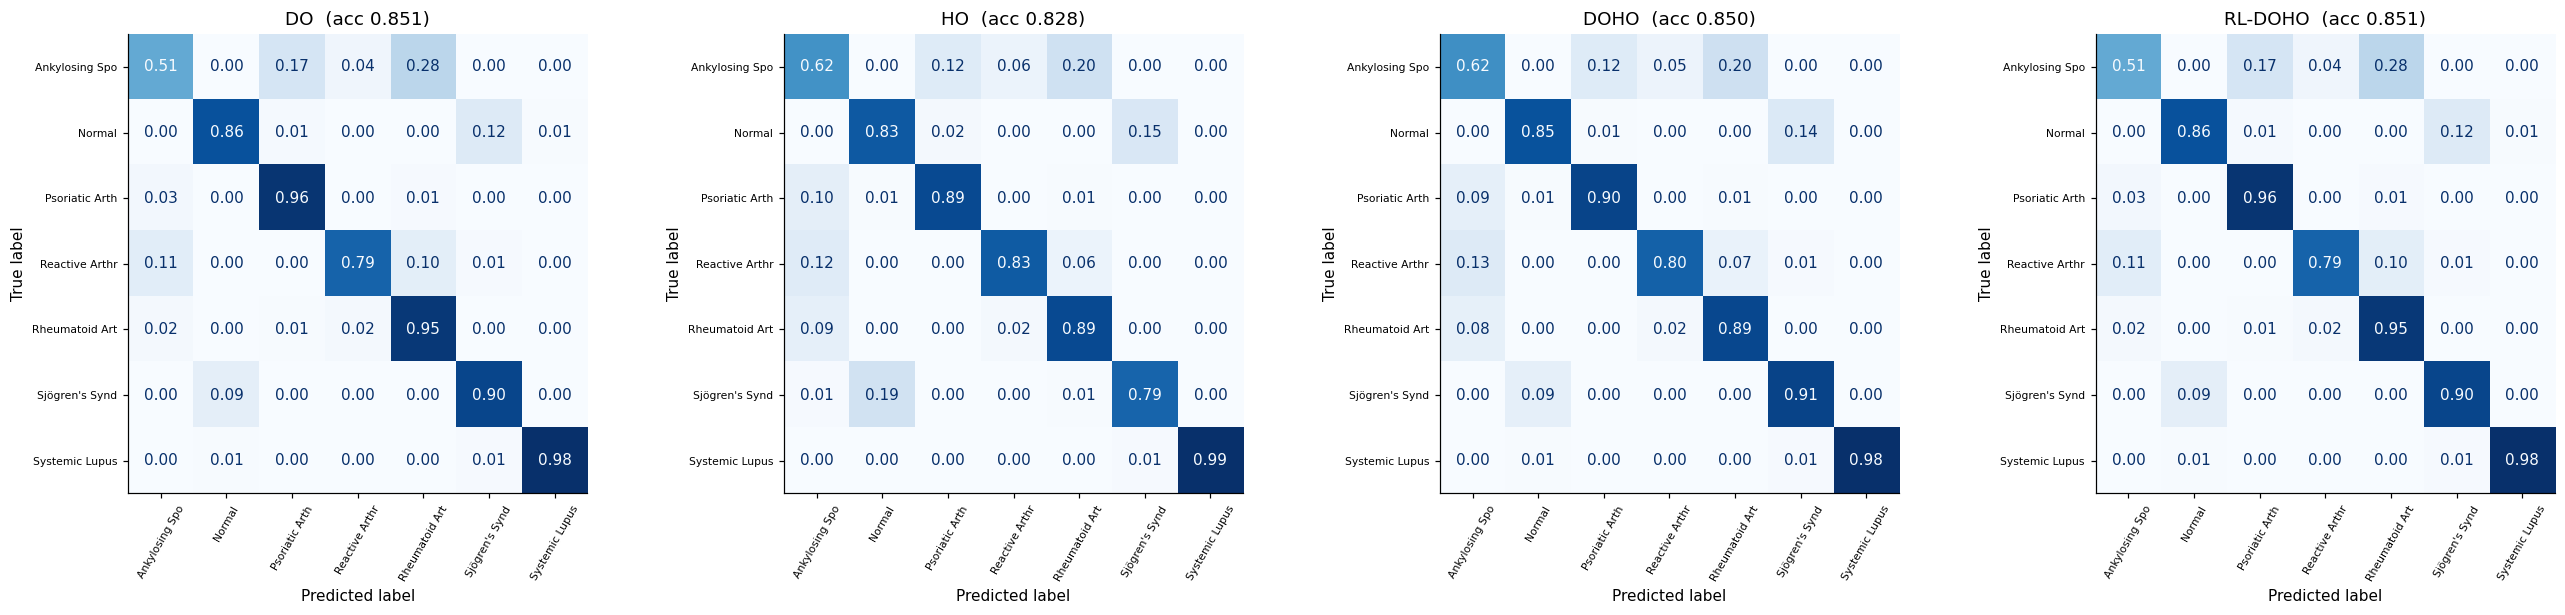

In [ ]:
# Confusion matrices: one per algorithm (XGB predictions on the test set)
short = [c[:14] for c in CLASS_NAMES]
fig, ax = plt.subplots(1, len(ALGOS), figsize=(6 * len(ALGOS), 5.5))
for k, a in enumerate(ALGOS):
    cm = confusion_matrix(y_test, detail[a]["test"]["XGB"]["pred"], normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=short).plot(ax=ax[k], cmap="Blues", colorbar=False, values_format=".2f")
    ax[k].set_title(f"{a}  (acc {detail[a]['test']['XGB']['acc']:.3f})"); ax[k].grid(False)
    ax[k].tick_params(axis="x", rotation=60, labelsize=7); ax[k].tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/04_confusion.png", bbox_inches="tight"); plt.show()

### 6d. Is the accuracy gap real? McNemar test and bootstrap 95% CI
If McNemar p > 0.05, the two algorithms' test accuracies are statistically indistinguishable.

Test set: 2417 patients -> 1 patient = 0.041% accuracy

--- XGB, seed 42 ---
  DO       acc=0.8511  95% CI [0.8362, 0.8651]
  HO       acc=0.8279  95% CI [0.8130, 0.8424]
  DOHO     acc=0.8498  95% CI [0.8353, 0.8635]
  RL-DOHO  acc=0.8511  95% CI [0.8362, 0.8651]
  McNemar RL-DOHO vs DO     : identical feature subset
  McNemar RL-DOHO vs HO     : only RL-DOHO right=151, only HO right= 95, p=0.0004 -> significant
  McNemar RL-DOHO vs DOHO   : only RL-DOHO right= 86, only DOHO right= 83, p=0.8778 -> NOT significant (indistinguishable)
--- HGB, seed 42 ---
  DO       acc=0.8420  95% CI [0.8275, 0.8564]
  HO       acc=0.8213  95% CI [0.8064, 0.8366]
  DOHO     acc=0.8424  95% CI [0.8275, 0.8568]
  RL-DOHO  acc=0.8420  95% CI [0.8275, 0.8564]
  McNemar RL-DOHO vs DO     : identical feature subset
  McNemar RL-DOHO vs HO     : only RL-DOHO right=160, only HO right=110, p=0.0028 -> significant
  McNemar RL-DOHO vs DOHO   : only RL-DOHO right=103, only DOHO right=104, p=1.0000 -> NOT signific

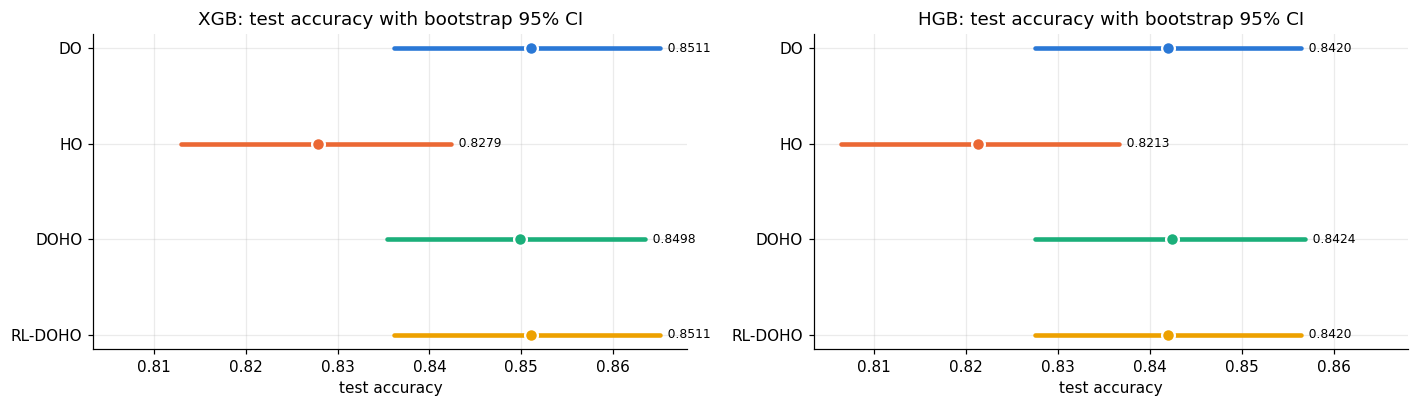

In [ ]:
from scipy.stats import binomtest

def mcnemar(pred_a, pred_b):
    a_ok, b_ok = pred_a == y_test, pred_b == y_test
    n_a_only, n_b_only = int(np.sum(a_ok & ~b_ok)), int(np.sum(~a_ok & b_ok))
    n = n_a_only + n_b_only
    return n_a_only, n_b_only, (binomtest(min(n_a_only, n_b_only), n, 0.5).pvalue if n else 1.0)

def boot_ci(pred, B=2000, seed=0):
    ok = (pred == y_test).astype(float); r = np.random.default_rng(seed)
    return np.percentile([ok[r.integers(0, len(ok), len(ok))].mean() for _ in range(B)], [2.5, 97.5])

print(f"Test set: {len(y_test)} patients -> 1 patient = {100/len(y_test):.3f}% accuracy\n")
ci_rows = []
for model in ["XGB", "HGB"]:
    print(f"--- {model}, seed {DETAIL_SEED} ---")
    preds = {a: detail[a]["test"][model]["pred"] for a in ALGOS}
    for a in ALGOS:
        acc = np.mean(preds[a] == y_test); lo, hi = boot_ci(preds[a])
        ci_rows.append((model, a, acc, lo, hi))
        print(f"  {a:8s} acc={acc:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
    for a in [x for x in ALGOS if x != PROPOSED]:
        if mask_str(detail[a]["mask"]) == mask_str(detail[PROPOSED]["mask"]):
            print(f"  McNemar {PROPOSED} vs {a:7s}: identical feature subset"); continue
        n1, n2, p = mcnemar(preds[PROPOSED], preds[a])
        verdict = "significant" if p < 0.05 else "NOT significant (indistinguishable)"
        print(f"  McNemar {PROPOSED} vs {a:7s}: only {PROPOSED} right={n1:3d}, only {a} right={n2:3d}, p={p:.4f} -> {verdict}")

ci = pd.DataFrame(ci_rows, columns=["model", "algo", "acc", "lo", "hi"])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), sharex=True)
for k, model in enumerate(["XGB", "HGB"]):
    d = ci[ci.model == model].reset_index(drop=True)
    for i, r in d.iterrows():
        ax[k].plot([r.lo, r.hi], [i, i], color=COLORS[r.algo], lw=3, solid_capstyle="round")
        ax[k].scatter(r.acc, i, color=COLORS[r.algo], s=70, zorder=3, edgecolor="white", linewidth=1.5)
        ax[k].text(r.hi, i, f"  {r.acc:.4f}", va="center", fontsize=8)
    ax[k].set_yticks(range(len(d))); ax[k].set_yticklabels(d.algo); ax[k].invert_yaxis()
    ax[k].set_title(f"{model}: test accuracy with bootstrap 95% CI"); ax[k].set_xlabel("test accuracy")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/04b_accuracy_ci.png", bbox_inches="tight"); plt.show()

## 7. Benchmark over SEEDS (resumable; with SEEDS=[42] it just reuses section 6)
Each (algorithm, seed) run is saved as soon as it finishes. If Colab disconnects, rerun this cell and it skips finished runs.

In [ ]:
RES_FILE  = f"{OUT_DIR}/final_runs_p{POP_SIZE}_i{MAX_ITER}_a{ALPHA}_st{STAG_TRIGGER}_tie{TIE_EPS}.pkl"
PREV_FILE = f"{OUT_DIR}/benchmark_runs_p{POP_SIZE}_i{MAX_ITER}_a{ALPHA}_st{STAG_TRIGGER}_tie{TIE_EPS}.pkl"  # earlier 5-algorithm run
runs = pickle.load(open(RES_FILE, "rb")) if os.path.exists(RES_FILE) else {}
PREV = pickle.load(open(PREV_FILE, "rb")) if os.path.exists(PREV_FILE) else {}
# DO / HO / DOHO are unchanged and deterministic per seed, so their earlier runs are reused as-is
for (a_, s_), r_ in PREV.items():
    if a_ in ("DO", "HO", "DOHO") and (a_, s_) not in runs: runs[(a_, s_)] = r_
print(f"{len(runs)} runs already available ({len(PREV)} found in the earlier results file)")
t_start = time.time()
for s in SEEDS:
    for a in ALGOS:
        if (a, s) in runs: continue
        if s == DETAIL_SEED and a in detail:                   # reuse the detailed run, no need to repeat it
            m, f, h = detail[a]["mask"], detail[a]["fit"], detail[a]["hist"]
        else:
            m, f, h = RUNNERS[a](seed=s, verbose=VERBOSE)
        te = evaluate_on_test(m, a, verbose=False)
        runs[(a, s)] = {"mask": m, "fit": f, "hist": h, "cv_acc": _cache[mask_str(m)]["acc"],
                        "test_acc": te["acc"], "test_f1": te["f1"], "n_feats": int(m.sum())}
        pickle.dump(runs, open(RES_FILE, "wb"))
        print(f"\n  [{time.strftime('%H:%M:%S')}] seed {s} {a:8s} fit={f:.4f} test={te['acc']:.4f} feats={int(m.sum())}", flush=True)
    print(f"\n######## seed {s} finished | " + "  ".join(
        f"{a}: fit={runs[(a, s)]['fit']:.4f} acc={runs[(a, s)]['test_acc']:.4f} f={runs[(a, s)]['n_feats']}" for a in ALGOS)
        + f" | elapsed {time.time() - t_start:.0f}s ########")

summary = pd.DataFrame([{"algo": a, "seed": s, **{k: v for k, v in r.items() if k not in ("mask", "hist")},
                         "mask": mask_str(r["mask"])} for (a, s), r in runs.items() if s in SEEDS])
summary.to_csv(f"{OUT_DIR}/benchmark_per_run.csv", index=False)
table = summary.groupby("algo").agg(fit_mean=("fit", "mean"), fit_std=("fit", "std"),
                                    cv_acc_mean=("cv_acc", "mean"), cv_acc_std=("cv_acc", "std"), test_acc_mean=("test_acc", "mean"),
                                    test_acc_std=("test_acc", "std"), test_f1=("test_f1", "mean"),
                                    n_feats=("n_feats", "mean"), distinct_masks=("mask", "nunique")).reindex(ALGOS)
table.to_csv(f"{OUT_DIR}/benchmark_summary.csv")
table.round(4)

24 runs already available (38 found in the earlier results file)
......
  [11:57:41] seed 0 RL-DOHO  fit=0.1820 test=0.8465 feats=10

######## seed 0 finished | DO: fit=0.1820 acc=0.8465 f=10  HO: fit=0.1835 acc=0.8426 f=13  DOHO: fit=0.1820 acc=0.8465 f=10  RL-DOHO: fit=0.1820 acc=0.8465 f=10 | elapsed 119s ########
.
  [11:58:22] seed 1 RL-DOHO  fit=0.1820 test=0.8465 feats=10

######## seed 1 finished | DO: fit=0.1929 acc=0.8362 f=11  HO: fit=0.1980 acc=0.8287 f=8  DOHO: fit=0.1929 acc=0.8362 f=11  RL-DOHO: fit=0.1820 acc=0.8465 f=10 | elapsed 159s ########
...
  [11:59:23] seed 2 RL-DOHO  fit=0.1830 test=0.8490 feats=10

######## seed 2 finished | DO: fit=0.1856 acc=0.8453 f=10  HO: fit=0.1924 acc=0.8302 f=9  DOHO: fit=0.1890 acc=0.8475 f=11  RL-DOHO: fit=0.1830 acc=0.8490 f=10 | elapsed 220s ########
.......
  [12:02:06] seed 3 RL-DOHO  fit=0.1822 test=0.8461 feats=11

######## seed 3 finished | DO: fit=0.1889 acc=0.8457 f=12  HO: fit=0.1821 acc=0.8382 f=12  DOHO: fit=0.1856 acc=0

,fit_mean,fit_std,cv_acc_mean,cv_acc_std,test_acc_mean,test_acc_std,test_f1,n_feats,distinct_masks
algo,,,,,,,,,
DO,0.1871,0.0061,0.8185,0.0065,0.8414,0.0093,0.8365,10.3,8
HO,0.1880,0.0071,0.8177,0.0081,0.8379,0.0097,0.8332,10.6,9
DOHO,0.1882,0.0038,0.8176,0.0038,0.8403,0.0067,0.8346,10.7,10
RL-DOHO,0.1845,0.0038,0.8208,0.0042,0.8434,0.0076,0.8379,9.9,7


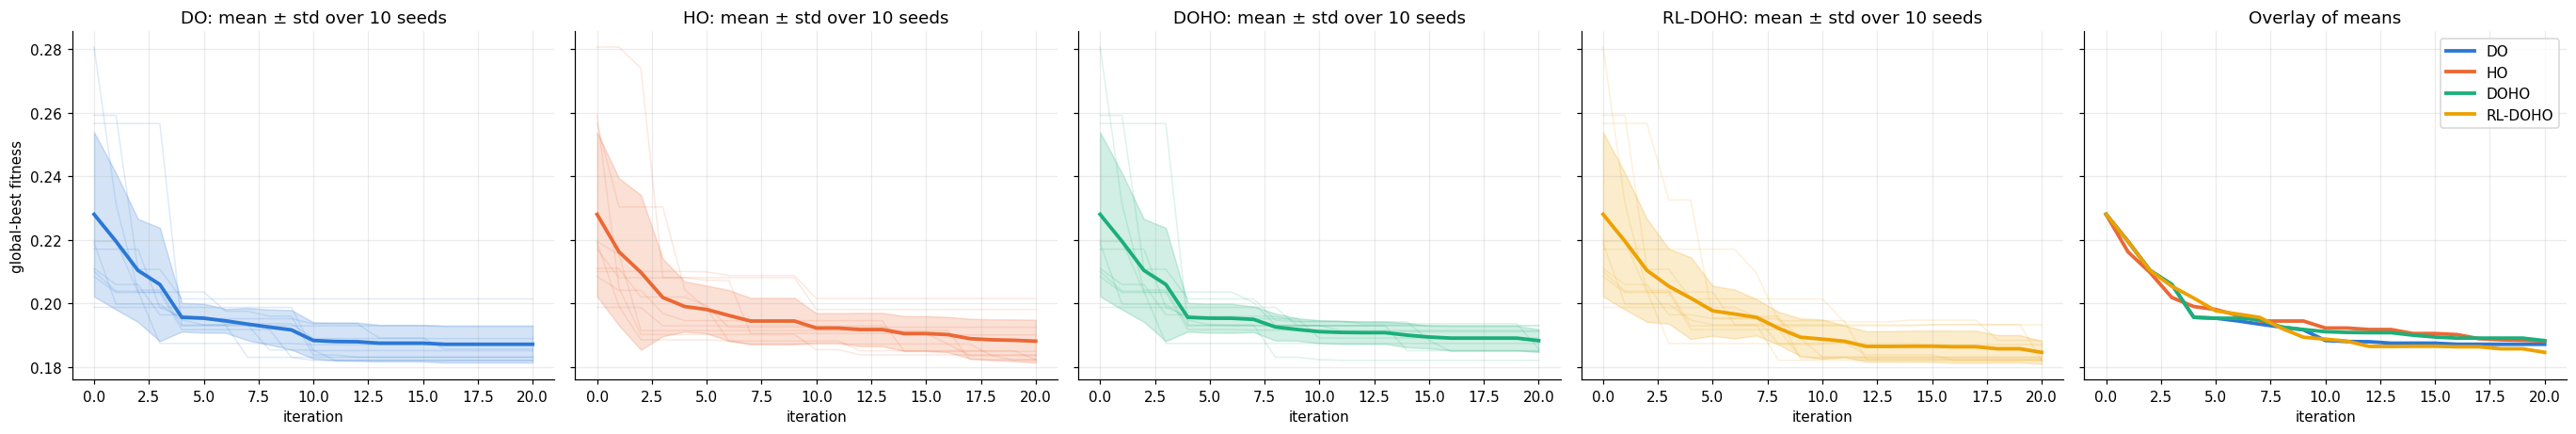

In [ ]:
# Mean convergence +/- std across seeds: one panel per algorithm, plus an overlay
NA = len(ALGOS)
fig, ax = plt.subplots(1, NA + 1, figsize=(5 * (NA + 1), 4.3), sharey=True)
for k, a in enumerate(ALGOS):
    B = np.vstack([runs[(a, s)]["hist"]["best"].values for s in SEEDS])
    mu, sd = B.mean(0), B.std(0); x = np.arange(B.shape[1])
    for row in B: ax[k].plot(x, row, color=COLORS[a], alpha=0.15, lw=1)
    ax[k].fill_between(x, mu - sd, mu + sd, color=COLORS[a], alpha=0.2)
    ax[k].plot(x, mu, color=COLORS[a], lw=2.5); ax[k].set_title(f"{a}: mean ± std over {len(SEEDS)} seeds")
    ax[k].set_xlabel("iteration")
    ax[NA].plot(x, mu, color=COLORS[a], lw=2.5, label=a)
ax[0].set_ylabel("global-best fitness"); ax[NA].set_title("Overlay of means"); ax[NA].legend(); ax[NA].set_xlabel("iteration")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/05_mean_convergence.png", bbox_inches="tight"); plt.show()

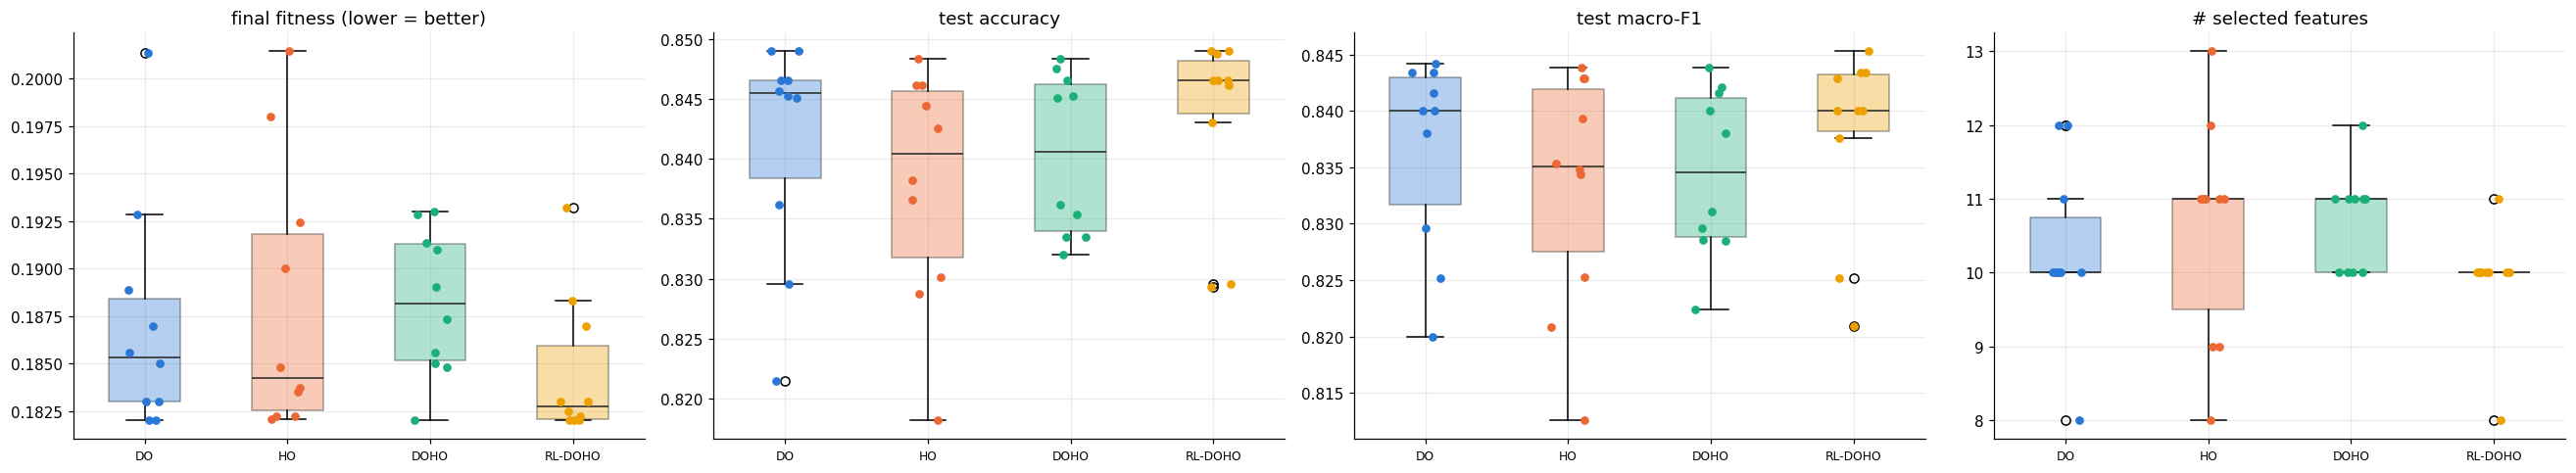

In [ ]:
# Distributions across seeds: final fitness, test accuracy, macro-F1, #features
metrics = [("fit", "final fitness (lower = better)"), ("test_acc", "test accuracy"),
           ("test_f1", "test macro-F1"), ("n_feats", "# selected features")]
fig, ax = plt.subplots(1, 4, figsize=(24, 4.5))
rng_j = np.random.default_rng(0)
for k, (col, title) in enumerate(metrics):
    data = [summary[summary.algo == a][col].values for a in ALGOS]
    bp = ax[k].boxplot(data, widths=0.5, patch_artist=True, medianprops=dict(color="#222"))
    for patch, a in zip(bp["boxes"], ALGOS): patch.set_facecolor(COLORS[a]); patch.set_alpha(0.35)
    for i, (d, a) in enumerate(zip(data, ALGOS)):
        ax[k].scatter(i + 1 + rng_j.uniform(-0.12, 0.12, len(d)), d, color=COLORS[a], s=22, zorder=3)
    ax[k].set_xticks(range(1, len(ALGOS) + 1)); ax[k].set_xticklabels(ALGOS, fontsize=8); ax[k].set_title(title)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/06_boxplots.png", bbox_inches="tight"); plt.show()

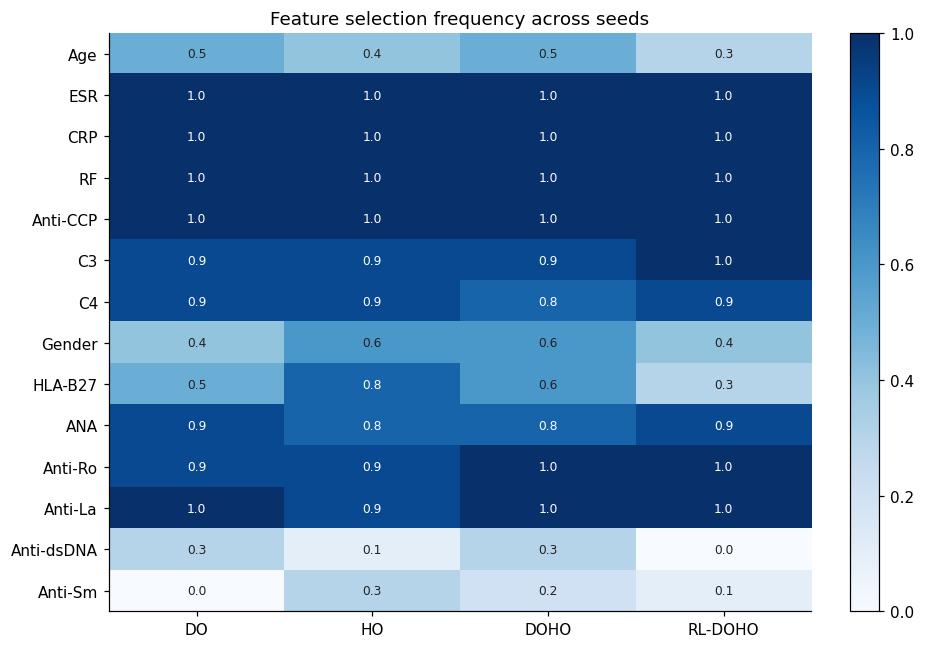

In [ ]:
# How often each feature was selected (fraction of seeds), per algorithm
freq = pd.DataFrame({a: np.mean([runs[(a, s)]["mask"] for s in SEEDS], axis=0) for a in ALGOS}, index=FEATURES)
fig, ax = plt.subplots(figsize=(8.5, 6))
im = ax.imshow(freq.values, cmap="Blues", vmin=0, vmax=1, aspect="auto"); ax.grid(False)
ax.set_xticks(range(len(ALGOS))); ax.set_xticklabels(ALGOS); ax.set_yticks(range(N_FEATURES)); ax.set_yticklabels(FEATURES)
for i in range(N_FEATURES):
    for j in range(len(ALGOS)):
        v = freq.values[i, j]; ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white" if v > 0.6 else "#222")
ax.set_title("Feature selection frequency across seeds"); plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/07_feature_frequency.png", bbox_inches="tight"); plt.show()

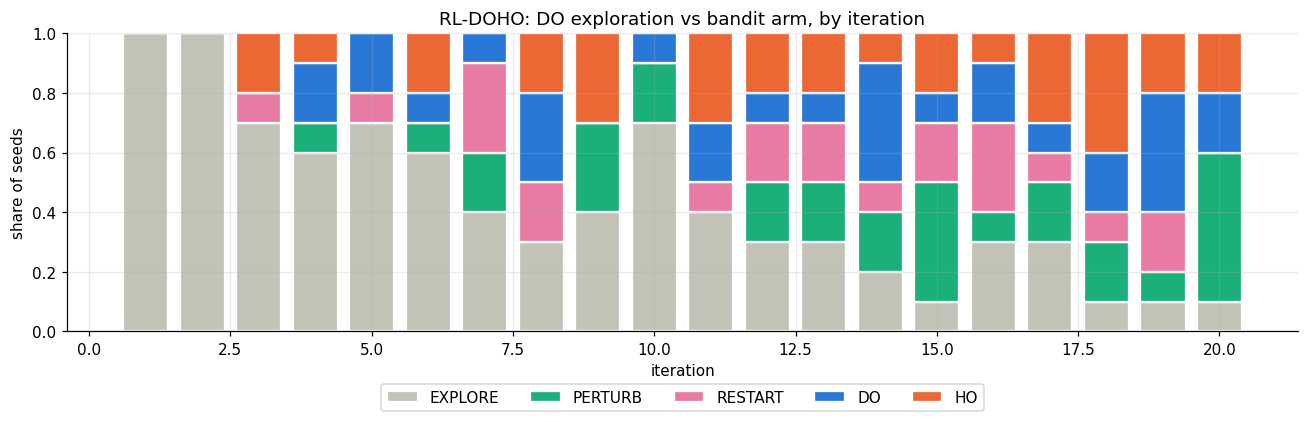

In [ ]:
# RL-DOHO: what it did at each iteration, across seeds
acts = ["EXPLORE"] + list(ARMS)
A = pd.DataFrame([runs[(PROPOSED, s)]["hist"]["arm"].values[1:] for s in SEEDS])
share = pd.DataFrame({act: (A == act).mean(0).values for act in acts}, index=range(1, MAX_ITER + 1))
a_col = ARM_COL
fig, ax = plt.subplots(figsize=(12, 4))
bottom = np.zeros(MAX_ITER)
for act in acts:
    ax.bar(share.index, share[act], bottom=bottom, color=a_col[act], width=0.8, label=act, edgecolor="white", lw=1.5)
    bottom += share[act].values
ax.set_xlabel("iteration"); ax.set_ylabel("share of seeds"); ax.set_title("RL-DOHO: DO exploration vs bandit arm, by iteration")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/08_rl_doho_arm_share.png", bbox_inches="tight"); plt.show()

## 8. Statistical tests

In [ ]:
F = np.array([[runs[(a, s)]["fit"] for a in ALGOS] for s in SEEDS])
ACC = np.array([[runs[(a, s)]["test_acc"] for a in ALGOS] for s in SEEDS])

def friedman(M, label):
    try:
        st, p = friedmanchisquare(*M.T); print(f"Friedman on {label}: chi2={st:.3f}, p={p:.4f}")
    except ValueError as e: print(f"Friedman on {label}: not computable ({e})")

def pairwise(M, label, higher_better):
    print(f"\nWilcoxon signed-rank, {PROPOSED} vs others ({label}):")
    j = ALGOS.index(PROPOSED)
    for i, a in enumerate(ALGOS):
        if a == PROPOSED: continue
        d = M[:, j] - M[:, i]
        wins = int(np.sum(d > 0) if higher_better else np.sum(d < 0)); ties = int(np.sum(d == 0)); losses = len(d) - wins - ties
        try:   p = wilcoxon(M[:, j], M[:, i], zero_method="zsplit").pvalue
        except ValueError: p = np.nan
        print(f"  vs {a:5s}: W/T/L = {wins}/{ties}/{losses}   mean diff = {d.mean():+.4f}   p = {p:.4f}")

if len(SEEDS) >= 6:
    friedman(F, "fitness"); friedman(ACC, "test accuracy")
    pairwise(F, "fitness, lower is better", higher_better=False)
    pairwise(ACC, "test accuracy", higher_better=True)
else:
    print(f"Only {len(SEEDS)} seed(s): Friedman/Wilcoxon need >= 6 seeds, skipped. Set SEEDS = list(range(10)) for the paper.")

print("\nTest accuracy across seeds (stability):")
for a in ALGOS:
    v = summary[summary.algo == a]["test_acc"]
    print(f"  {a:8s} mean={v.mean():.4f}  std={(v.std() if len(v) > 1 else 0):.4f}  worst={v.min():.4f}  best={v.max():.4f}  "
          f"mean #features={summary[summary.algo == a]['n_feats'].mean():.1f}")
avg_rank = pd.DataFrame(F, columns=ALGOS).rank(axis=1).mean().sort_values()
print("\nAverage rank on fitness (1 = best):"); print(avg_rank.round(2).to_string())

Friedman on fitness: chi2=5.044, p=0.1686
Friedman on test accuracy: chi2=10.187, p=0.0170

Wilcoxon signed-rank, RL-DOHO vs others (fitness, lower is better):
  vs DO   : W/T/L = 5/4/1   mean diff = -0.0026   p = 0.1562
  vs HO   : W/T/L = 7/0/3   mean diff = -0.0035   p = 0.1934
  vs DOHO : W/T/L = 7/1/2   mean diff = -0.0037   p = 0.0742

Wilcoxon signed-rank, RL-DOHO vs others (test accuracy):
  vs DO   : W/T/L = 4/4/2   mean diff = +0.0020   p = 0.5000
  vs HO   : W/T/L = 9/0/1   mean diff = +0.0055   p = 0.0488
  vs DOHO : W/T/L = 6/1/3   mean diff = +0.0031   p = 0.4023

Test accuracy across seeds (stability):
  DO       mean=0.8414  std=0.0093  worst=0.8215  best=0.8490  mean #features=10.3
  HO       mean=0.8379  std=0.0097  worst=0.8182  best=0.8484  mean #features=10.6
  DOHO     mean=0.8403  std=0.0067  worst=0.8320  best=0.8484  mean #features=10.7
  RL-DOHO  mean=0.8434  std=0.0076  worst=0.8293  best=0.8490  mean #features=9.9

Average rank on fitness (1 = best):
RL-DOHO

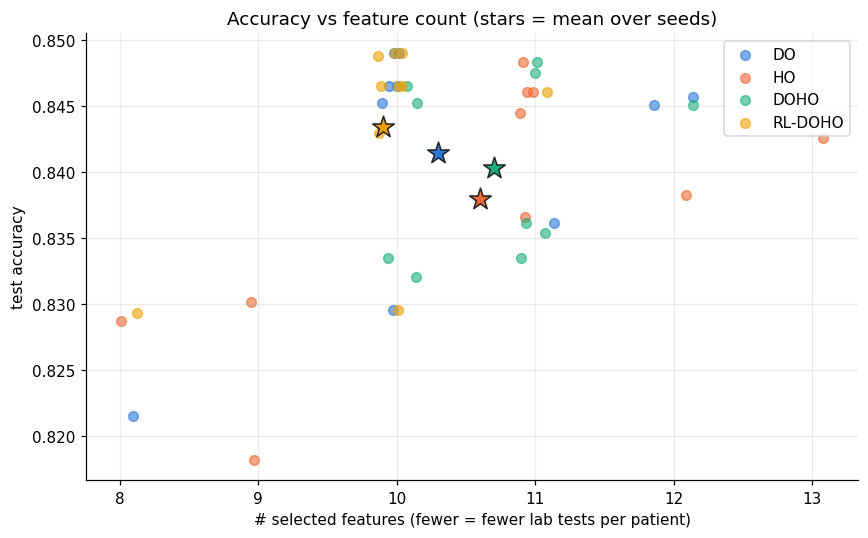

In [ ]:
# Accuracy vs number of features, every run (up-left = better)
fig, ax = plt.subplots(figsize=(8, 5))
jit = np.random.default_rng(1)
for a in ALGOS:
    d = summary[summary.algo == a]
    ax.scatter(d["n_feats"] + jit.uniform(-0.15, 0.15, len(d)), d["test_acc"], color=COLORS[a], s=40, alpha=0.6, label=a)
    if len(d) > 1:
        ax.scatter(d["n_feats"].mean(), d["test_acc"].mean(), color=COLORS[a], s=220, marker="*", edgecolor="#222", zorder=5)
ax.set_xlabel("# selected features (fewer = fewer lab tests per patient)"); ax.set_ylabel("test accuracy")
ax.set_title("Accuracy vs feature count" + (" (stars = mean over seeds)" if len(SEEDS) > 1 else f" (seed {SEEDS[0]})"))
ax.legend(); plt.tight_layout(); plt.savefig(f"{OUT_DIR}/11_pareto.png", bbox_inches="tight"); plt.show()

## 9. Ablation: which parts of RL-DOHO matter?
Each row changes one component of RL-DOHO and keeps everything else the same. 'Random arm' tests the RL controller itself; 'Without HO arm' tests what HO adds; 'Q-learning controller' is the previous RL-DOHO; 'No local search' is plain DO.

  [12:20:04] ablation seed 0 RL-DOHO (4-arm bandit)   fit=0.1820
..  [12:20:48] ablation seed 0 Random arm               fit=0.1830
  [12:20:48] ablation seed 0 Without HO arm (3 arms)  fit=0.1820
...  [12:22:19] ablation seed 0 PERTURB only             fit=0.1825
.  [12:22:45] ablation seed 0 Without tie-break        fit=0.1821
  [12:22:45] ablation seed 0 Q-learning controller    fit=0.1825
  [12:22:45] ablation seed 0 No local search (= DO)   fit=0.1820
  [12:22:45] ablation seed 1 RL-DOHO (4-arm bandit)   fit=0.1820
..  [12:23:20] ablation seed 1 Random arm               fit=0.1821
  [12:23:20] ablation seed 1 Without HO arm (3 arms)  fit=0.1898
.  [12:23:46] ablation seed 1 PERTURB only             fit=0.1820
  [12:23:56] ablation seed 1 Without tie-break        fit=0.1883
  [12:23:56] ablation seed 1 Q-learning controller    fit=0.1931
  [12:23:56] ablation seed 1 No local search (= DO)   fit=0.1929
  [12:23:56] ablation seed 2 RL-DOHO (4-arm bandit)   fit=0.1830
..  [12:24:43] a

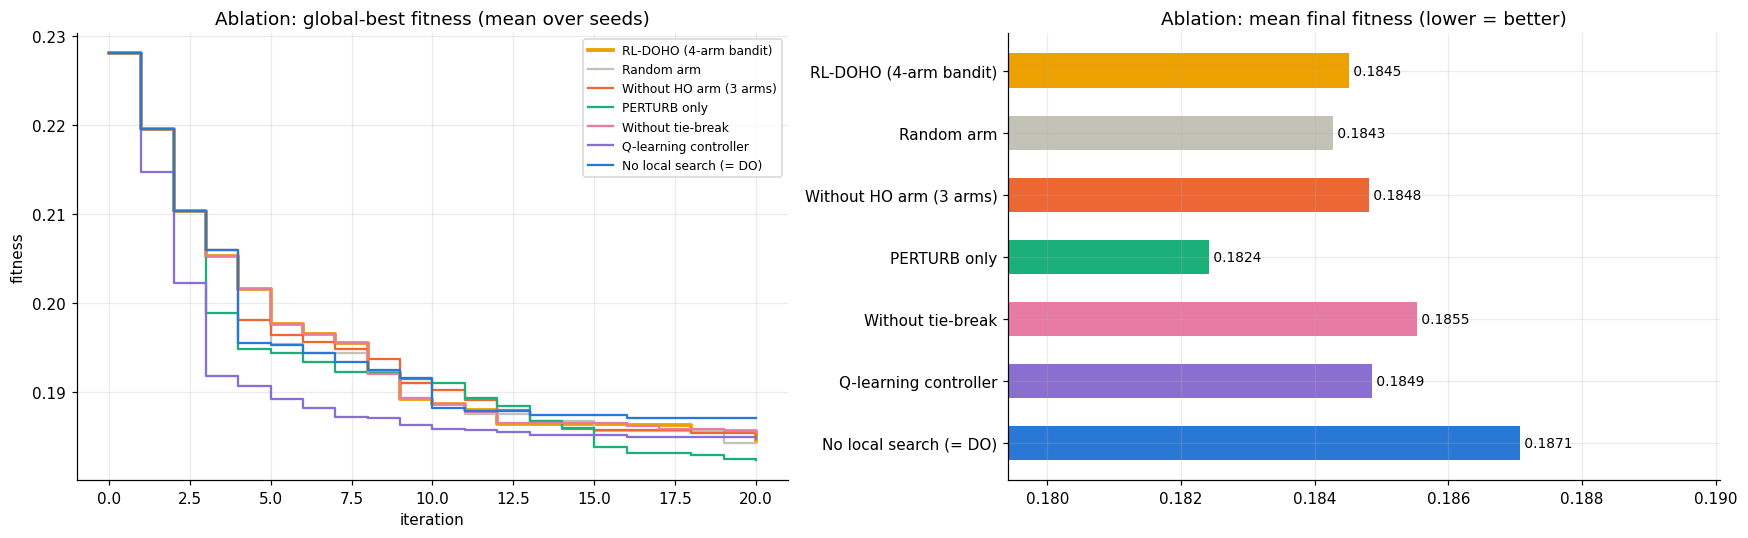

In [ ]:
B4 = dict(verbose=VERBOSE)
ABL = {   # name -> (where an earlier result may already exist, function that runs it)
    "RL-DOHO (4-arm bandit)":   (("runs", PROPOSED), None),
    "Random arm":               (None, lambda s, n: rl_doho(seed=s, name=n, bandit=lambda sd: RandomArm(n_arms=4, seed=sd), **B4)),
    "Without HO arm (3 arms)":  (("prev", "UCB-DOHO"), lambda s, n: rl_doho(seed=s, name=n, arms=("PERTURB", "RESTART", "DO"), **B4)),
    "PERTURB only":             (None, lambda s, n: rl_doho(seed=s, name=n, bandit=lambda sd: FixedArm(0, sd, n_arms=4), **B4)),
    "Without tie-break":        (None, lambda s, n: rl_doho(seed=s, name=n, tie_eps=0.0, **B4)),
    "Q-learning controller":    (("prev", "RL-DOHO"), lambda s, n: rl_doho_qlearning(seed=s, name=n, **B4)),
    "No local search (= DO)":   (("runs", "DO"), None),
}
ABL_NAMES = list(ABL)
ABL_COL = dict(zip(ABL_NAMES, ["#eda100", "#c3c2b7", "#eb6834", "#1baf7a", "#e87ba4", "#8a6fd1", "#2a78d6"]))

if RUN_ABLATION:
    ABL_FILE = f"{OUT_DIR}/final_ablation_p{POP_SIZE}_i{MAX_ITER}_a{ALPHA}_st{STAG_TRIGGER}_tie{TIE_EPS}.pkl"
    abl = pickle.load(open(ABL_FILE, "rb")) if os.path.exists(ABL_FILE) else {}
    for s in SEEDS:
        for name, (src, fn) in ABL.items():
            if (name, s) in abl: continue
            r = None
            if src and src[0] == "runs": r = runs.get((src[1], s))
            if src and src[0] == "prev": r = PREV.get((src[1], s))
            if r is not None:
                abl[(name, s)] = {"fit": r["fit"], "mask": r["mask"], "hist": r["hist"]}
            else:
                m, f, h = fn(s, name)
                abl[(name, s)] = {"fit": f, "mask": m, "hist": h}
            pickle.dump(abl, open(ABL_FILE, "wb"))
            print(f"  [{time.strftime('%H:%M:%S')}] ablation seed {s} {name:24s} fit={abl[(name, s)]['fit']:.4f}", flush=True)

    ab = pd.DataFrame([{"variant": n, "seed": s, "fit": abl[(n, s)]["fit"], "n_feats": int(abl[(n, s)]["mask"].sum()),
                        "cv_acc": _cache[mask_str(abl[(n, s)]["mask"])]["acc"],
                        "test_acc": evaluate_on_test(abl[(n, s)]["mask"], verbose=False)["acc"]}
                       for n in ABL_NAMES for s in SEEDS])
    ab.to_csv(f"{OUT_DIR}/ablation.csv", index=False)
    agg = ab.groupby("variant", sort=False).agg(fit_mean=("fit", "mean"), fit_std=("fit", "std"), fit_worst=("fit", "max"),
                                                cv_acc=("cv_acc", "mean"), test_acc_mean=("test_acc", "mean"),
                                                test_acc_std=("test_acc", "std"), n_feats=("n_feats", "mean")).reindex(ABL_NAMES)
    print("\n", agg.round(4).to_string())

    if len(SEEDS) >= 6:
        Fq = np.array([[abl[(n, s)]["fit"] for n in ABL_NAMES] for s in SEEDS])
        print("\nWilcoxon, full RL-DOHO vs each variant (fitness, lower is better):")
        for i in range(1, len(ABL_NAMES)):
            d = Fq[:, 0] - Fq[:, i]
            try: p = wilcoxon(Fq[:, 0], Fq[:, i], zero_method="zsplit").pvalue
            except ValueError: p = np.nan
            print(f"  vs {ABL_NAMES[i]:24s} W/T/L={np.sum(d < -1e-12)}/{np.sum(np.abs(d) <= 1e-12)}/{np.sum(d > 1e-12)}  "
                  f"mean diff={d.mean():+.4f}  p={p:.4f}")
    else:
        print("\n(Wilcoxon for the ablation needs >= 6 seeds.)")

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    for n in ABL_NAMES:
        B = np.vstack([abl[(n, s)]["hist"]["best"].values for s in SEEDS])
        ax[0].step(range(B.shape[1]), B.mean(0), where="post", color=ABL_COL[n], label=n, lw=2.5 if n == ABL_NAMES[0] else 1.5)
    ax[0].set_title("Ablation: global-best fitness" + (" (mean over seeds)" if len(SEEDS) > 1 else f" (seed {SEEDS[0]})"))
    ax[0].set_xlabel("iteration"); ax[0].set_ylabel("fitness"); ax[0].legend(fontsize=8)
    m_ = agg["fit_mean"]
    ax[1].barh(range(len(m_)), m_.values, color=[ABL_COL[n] for n in ABL_NAMES], height=0.55)
    for i, v in enumerate(m_.values): ax[1].text(v, i, f" {v:.4f}", va="center", fontsize=9)
    ax[1].set_yticks(range(len(m_))); ax[1].set_yticklabels(ABL_NAMES); ax[1].invert_yaxis()
    ax[1].set_xlim(m_.min() - 0.003, m_.max() + 0.003); ax[1].set_title("Ablation: mean final fitness (lower = better)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/10_ablation.png", bbox_inches="tight"); plt.show()

## 10. Ceiling check: is anything left to beat?
If every algorithm keeps landing on the same best mask, the problem is too small for a hybrid to show a gain. That is the barrier you have been hitting.

Unique masks evaluated so far: 4043 of 16383 (24.7% of the space)
Best fitness ever seen: 0.1820  mask=01111111011100

Top 10 masks ever evaluated:
             mask       fit    cv_acc  n_feats                        features dropped
0  01111111011100  0.181999  0.823377       10     [Age, HLA-B27, Anti-dsDNA, Anti-Sm]
1  11111111111100  0.182067  0.824752       12                   [Anti-dsDNA, Anti-Sm]
2  01111111111100  0.182217  0.823879       11              [Age, Anti-dsDNA, Anti-Sm]
3  01111110011101  0.182494  0.822877       10      [Age, Gender, HLA-B27, Anti-dsDNA]
4  01111111011101  0.182962  0.823127       11              [Age, HLA-B27, Anti-dsDNA]
5  11111110011100  0.182990  0.822376       10  [Gender, HLA-B27, Anti-dsDNA, Anti-Sm]
6  11111111111101  0.183523  0.824002       13                            [Anti-dsDNA]
7  11111111011100  0.183704  0.822377       11          [HLA-B27, Anti-dsDNA, Anti-Sm]
8  11111110111101  0.183922  0.822879       12                    [Ge

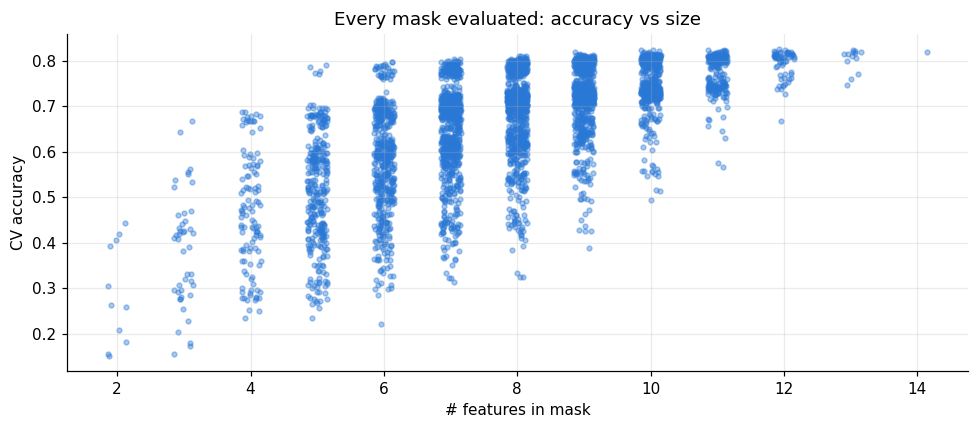


All figures, CSVs and caches are in: /content/drive/MyDrive/rl_doho_results


In [ ]:
all_evals = pd.DataFrame([{"mask": k, "fit": v["fit"], "cv_acc": v["acc"], "n_feats": k.count("1")} for k, v in _cache.items()])
all_evals = all_evals.sort_values("fit").reset_index(drop=True)
best_known = all_evals["fit"].iloc[0]
print(f"Unique masks evaluated so far: {len(all_evals)} of {2**N_FEATURES - 1} ({100*len(all_evals)/(2**N_FEATURES-1):.1f}% of the space)")
print(f"Best fitness ever seen: {best_known:.4f}  mask={all_evals['mask'].iloc[0]}")
print("\nTop 10 masks ever evaluated:")
top = all_evals.head(10).copy()
top["features dropped"] = top["mask"].apply(lambda m: [FEATURES[i] for i, b in enumerate(m) if b == "0"])
print(top.to_string())
print("\nRuns that reached the best-known fitness (within 1e-9):")
for a in ALGOS:
    hit = sum(abs(runs[(a, s)]["fit"] - best_known) < 1e-9 for s in SEEDS)
    gap = np.mean([runs[(a, s)]["fit"] - best_known for s in SEEDS])
    print(f"  {a:8s} {hit}/{len(SEEDS)} seeds, mean gap to best = {gap:.5f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(all_evals["n_feats"] + np.random.default_rng(0).uniform(-0.15, 0.15, len(all_evals)), all_evals["cv_acc"],
           s=10, color="#2a78d6", alpha=0.4)
ax.set_xlabel("# features in mask"); ax.set_ylabel("CV accuracy"); ax.set_title("Every mask evaluated: accuracy vs size")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/09_landscape.png", bbox_inches="tight"); plt.show()
print(f"\nAll figures, CSVs and caches are in: {OUT_DIR}")